    动态规划五部曲：
    1.确定dp数组含义
    2.递推关系
    3.初始化
    4.循环顺序
    5.


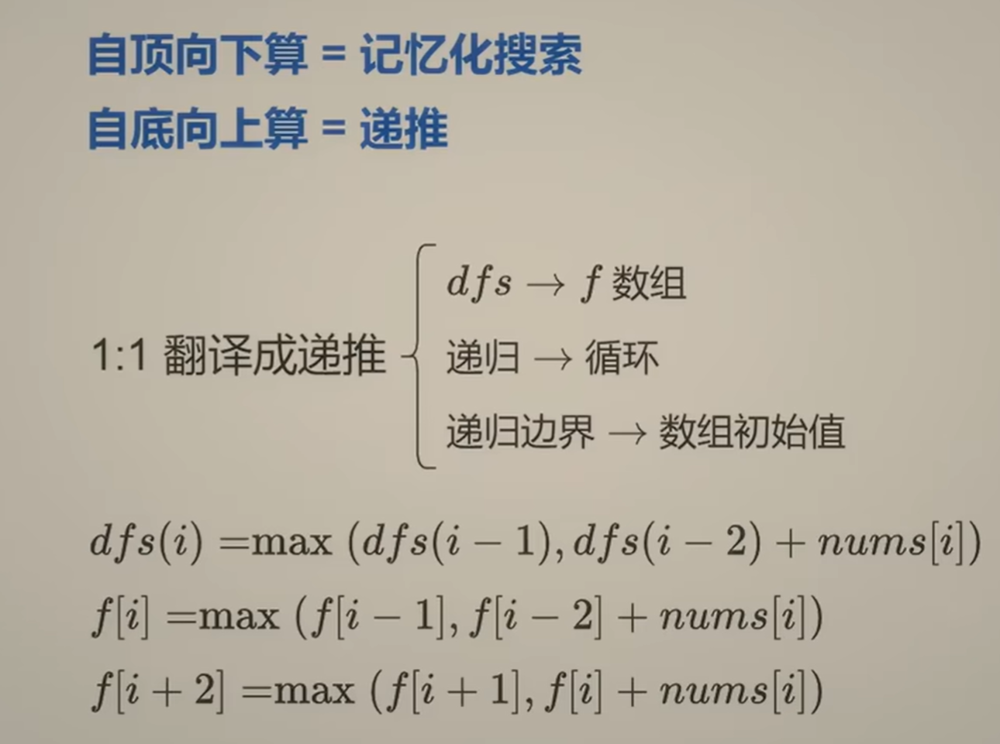

**_#1.打家劫舍问题：_**

使用动态规划的方法，而对于偷前i个房子的问题，它的最大值为偷取前i-1个房子与偷取前i-2个房子加上当前房子的价格的最大值，因此实际上只需使用两个变量记录i-1与i-2的值，不需要使用一个列表来完整记录每个索引的最大值

In [ ]:
class Solution(object):
    def rob(self, nums):
        f0 = f1 = 0#利用滚动数组的思想
        for i in nums:
            new_f = max(f1,f0+i)
            f0 = f1
            f1 = new_f

        return f1

_**#2.最大连续子数组乘积**_

这个问题的思路与求解最大连续子数组和很像，不同的点在于不仅要记录当前最大值，还要记录当前最小值，因为如果当前的数是一个负数的话，那么它乘以小值反而得到一个更大的值，因此在遇到负数的情况下，首先需要将之前的大值与小值互换，再继续判断

In [ ]:
class Solution(object):
    def maxProduct(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        min_num = max_num = curr_num = nums[0]
        n = len(nums)
        for i in range(1,n):

            if nums[i] < 0:
                min_num,curr_num = curr_num,min_num

            min_num = min(min_num * nums[i],nums[i])
            curr_num = max(curr_num * nums[i],nums[i])

            max_num = max(max_num,curr_num)

        return max_num

**_#3.目标和_**

01背包问题

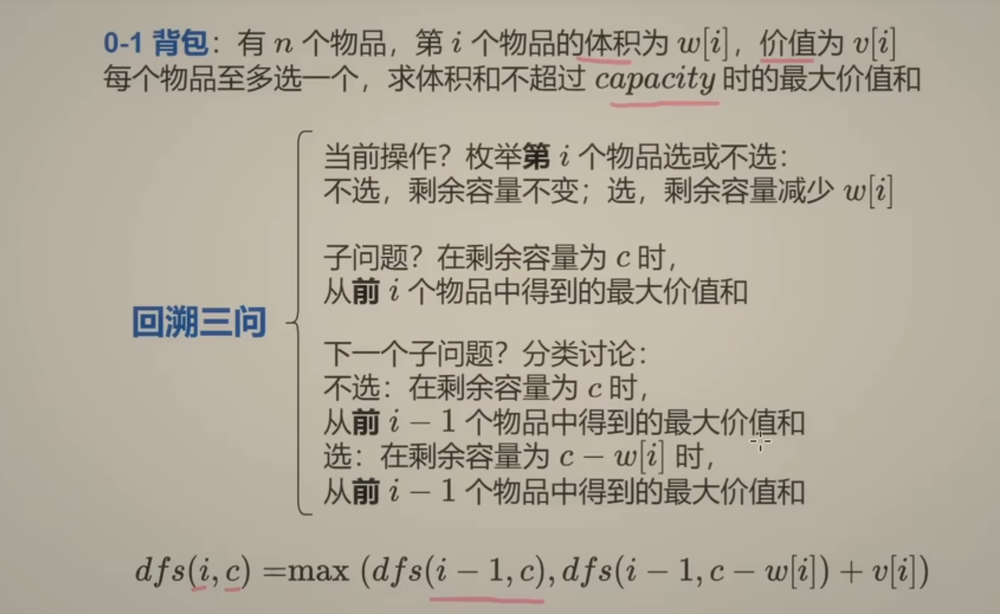

In [ ]:
class Solution:
    def findTargetSumWays(self, nums, target: int) -> int:
        target += sum(nums)

        if target < 0 or target % 2:
            return 0

        f = [0] * (target+1)#和为0-target的方案个数
        f[0] = 1#和为0的方案个数为1
        target //= 2

        for i in nums:
            for j in range(target,i-1,-1):#这个循环的意义在于只有背包的容量大于等于当前的物品时，更新方案数才是有意义的，否则的话因为当前的物品取不到，所以和为j的方案数还是以前算出来的结果
                f[j] = f[j] + f[j-i]#=号右边的f[j]代表以前算出来的不选第i个物品的方案数，f[j-i]代表选第i个物品的方案数

        return f[target]

In [ ]:
class Solution:
    def findTargetSumWays(self, nums, target: int) -> int:

        target += sum(nums)

        if target < 0 or target %2 :
            return 0

        target //= 2
        n = len(nums)
        f = [[0] * (target+1) for _ in range(n+1)]
        f[0][0] = 1

        for i,x in enumerate(nums):#遍历到第i+1件物品
            for c in range(target+1):
                if x > c:
                    f[i+1][c] = f[i][c]
                else:
                    f[i+1][c] = f[i][c] + f[i][c-x]#这个方法使用二维数组，之前的当容量为c时的方案个数都保存在f[i][c]下面，这个与一维数组写法不同，一维数组的先前值就保存在f[c]中，每次更新将其覆盖

        return f[n][target]

模板总结

 #求恰好等于target的方案数（01背包问题）

    #递归写法:
    def dfs(i,c):
        if i < 0:
            return 1 if c == 0 else 0
        elif nums[i] > c:
            return dfs(i-1,c)
        else:
            return dfs(i-1,c) + dfs(i-1,c-nums[i])#对于完全背包问题，这里改为dfs(i,c-nums[i])

        return dfs(n-1,target)

    #动态规划写法：
    f = [0] *  (target + 1)#存储的是上一个状态的值，也可以理解为用前i-1个物品去装一个容量依次为0-target的方案数
    f[0] = 1
    for i in nums:
        for j in range(target,i-1,-1):#对于完全背包问题，改为正序遍历即可
            f[j] = f[j] + f[j - i]
    return f[target]

#至多为target的方案数（01背包问题）

    def dfs(i,c):
        if i < 0:
            return 1 if c >=0 else 0
        elif c < nums[i]:
            return dfs(i-1,c)
        else:
            return dfs(i-1,c) + dfs(i-1,c - nums[i])


    f = [1] * (target + 1)#对所有的背包容量而言，当什么也不选的时候就有一个方案
    for i in nums:
        for j in range(target,i-1,-1):
            f[j] = f[j] + f[j - i]
    return f[target]

#至少为target的方案数（01背包问题）

    def dfs(i,c):
        if i < 0:
            return 1 if c <=0 else 0
        else:
            return dfs(i-1,c) + dfs(i-1,c - nums[i])


    f = [0] * (target + 1)
    f[0] = 1
    for i in nums:
        for j in range(target,-1,-1):
            f[j] = f[j] + f[j - i]
    return f[target]

#4.完全背包问题

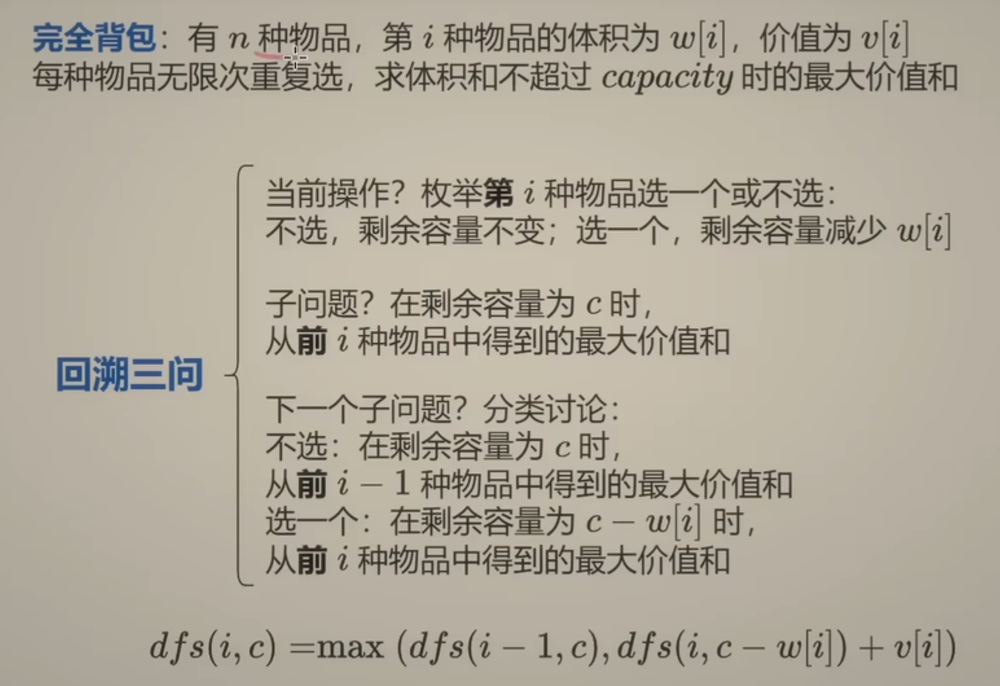
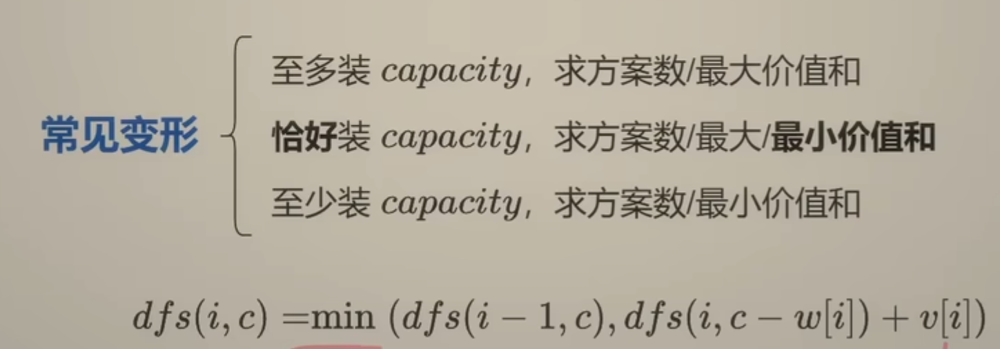
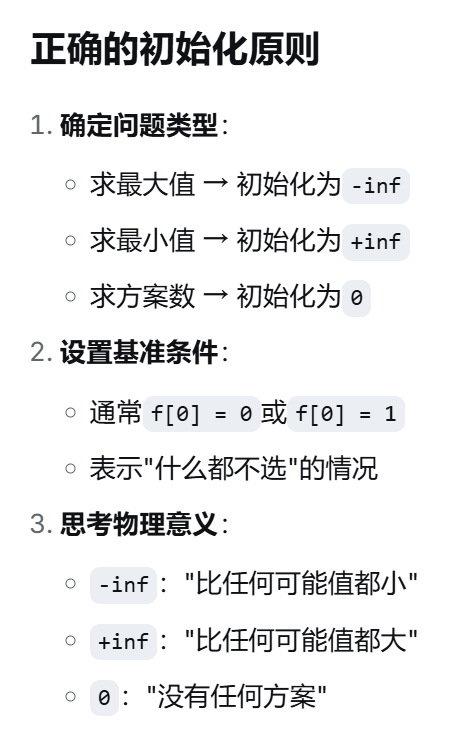

求最小价值时，初始化为inf，求最大价值时，初始化为-inf，同时最后返回结果的时候还要判断这个值是否有意义，也就是这个值能否被交换到

零钱兑换问题解决的是满足条件的最小硬币数量，完全背包问题

    class Solution:
    def coinChange(self, coins: List[int], amount: int) -> int:
        f = [inf] * (amount + 1)#设置为inf表示最初无法被兑换
        f[0] = 0

        for coin in coins:
            for j in range(coin,amount+1):
                f[j] = min(f[j],f[j-coin]+1)
        return f[amount] if f[amount] != inf else -1

这个变式解决的是满足条件的方案的个数

    class Solution:
        def change(self, amount: int, coins: List[int]) -> int:
            f = [0] * (amount+1)
            f[0] = 1

        for coin in coins:
            for j in range(coin,amount+1):#左闭右开，因此必须amount+1
                f[j] = f[j] + f[j-coin]

        return f[amount]

#零钱兑换的二维数组写法

    class Solution:
        def coinChange(self, coins: List[int], amount: int) -> int:
            m = len(coins)
            f = [[inf]*(amount+1) for _ in range(m+1)]
            f[0][0] = 0

        for i in range(m):#代表着处理的是哪一件物品，索引为i在f数组中应该放在i+1的位置上
            for j in range(amount+1):
                if j < coins[i]:
                    f[i+1][j] = f[i][j]
                else:
                    f[i+1][j] = min(f[i][j],f[i+1][j-coins[i]]+1)

        return f[m][amount] if f[m][amount]!= inf else -1



完全背包与01背包内部循环顺序不同的分析：


# 两类问题的核心转移方程：
    # 最大值版本
    f[j] = max(f[j], f[j-weight] + value)

    # 或计数版本：
    f[j] = f[j] + f[j-weight]

1.对于01背包问题，在使用一维数组记录结果的时候，内部循环在更新的时候是倒序，即

    for j in range(target, i-1, -1):
如果先对前面的j进行更新，那么更新后的j就是包含当前num的最大值或者方案数，而当f[j]用作f[j-weight]的时候，就又包含了一次当前的num，不满足只取一次的要求，因此需要倒序更新，**_倒序保证了：当我们计算 f[j] 时，f[j-weight] 还没有被当前物品更新过，所以它代表的是不考虑当前物品的状态。_**

2.而对于完全背包问题，内部循环更新是是正序，即：

    for j in range(i，target+1):
因为每个数据可以重复选取，因此我们需要判断j之前的数值是否可以更新，更加依赖本轮已经更新的状态

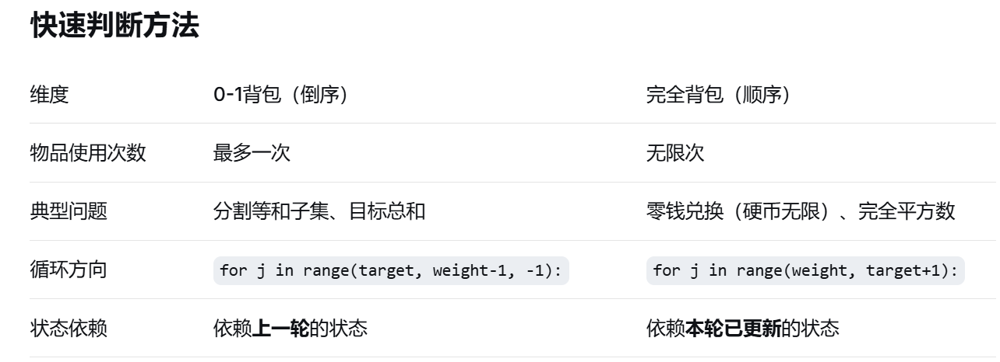

**_#5.线性dp问题_**

**_最长公共子序列的长度（lcs)_**
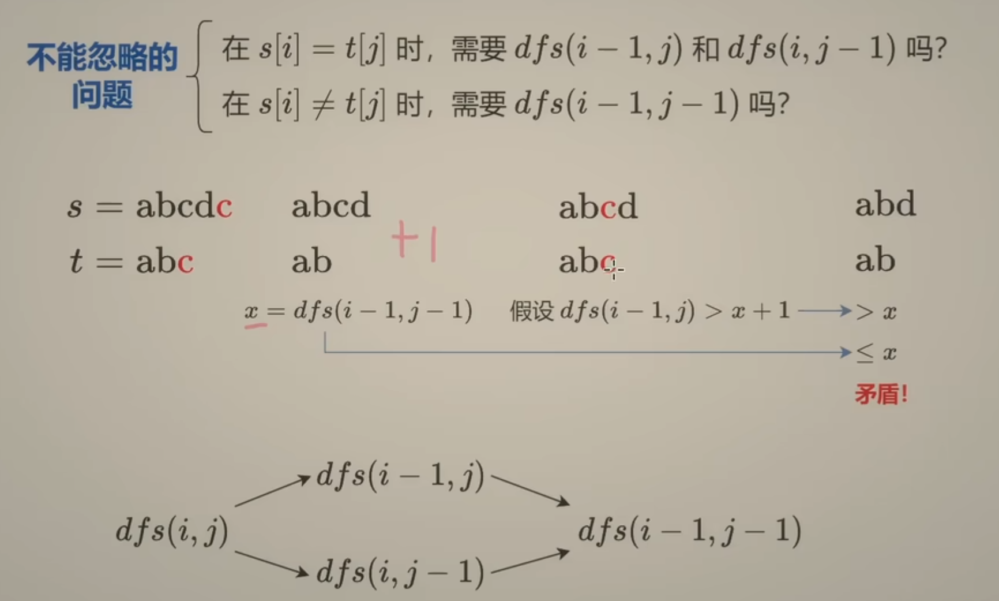
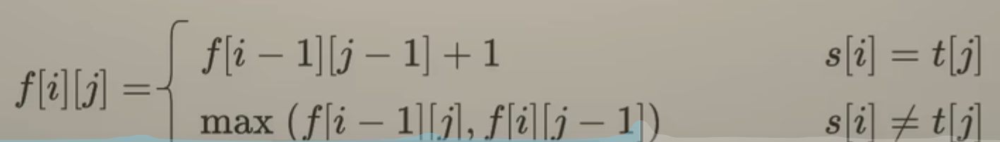

#当两个序列都没有重复元素时，将LCS问题转化为LIS问题：

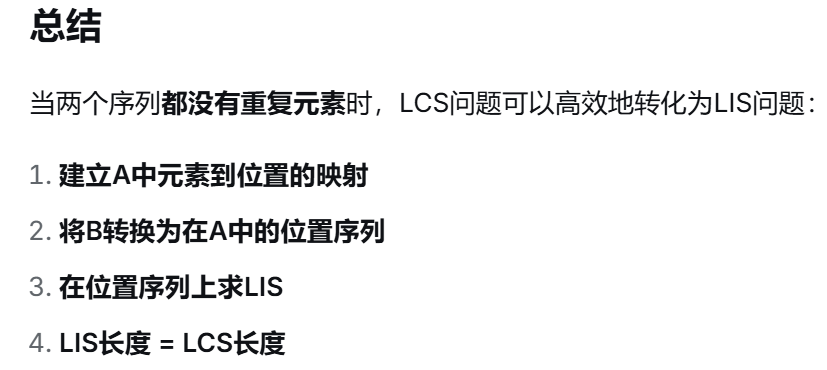

    from bisect import bisect_left

    def lcs_via_lis(A, B):
        """
        将LCS问题转化为LIS问题求解（要求A和B都没有重复元素）
        时间复杂度：O(n log n)
        """
        if not A or not B:
            return 0

        # 步骤1：建立A中元素到位置的映射（位置从1开始）
        pos_map = {}
        for i, num in enumerate(A):
            pos_map[num] = i + 1  # +1避免0，让位置从1开始

        # 步骤2：将B转换为在A中的位置序列（过滤掉A中没有的元素）
        pos_seq = []
        for num in B:
            if num in pos_map:
                pos_seq.append(pos_map[num])

        # 步骤3：在位置序列上求LIS
        g = []#数组g是严格递增的，又因为pos_seq存储的是A与B的公共元素在A中的位置索引，因此这些元素在A中的位置是严格递增的
        for x in pos_seq:#遍历的是A与B的公共元素，这个循环保证了元素在B中的位置是严格递增的
            j = bisect_left(g, x)
            if j == len(g):
                g.append(x)
            else:
                g[j] = x

        return len(g)


In [ ]:
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:

        m = len(text1)
        n = len(text2)
        f = [[0]*(n+1) for _ in range(m+1)]#f[i][j]的含义是从text1的前i个字符与text2的前j个字符对比，最长公共子序列的长度

        for i,x in enumerate(text1):
            for j,y in enumerate(text2):
                if x == y:
                    f[i+1][j+1] = 1 + f[i][j]
                else:
                    f[i+1][j+1] = max(f[i][j+1],f[i+1][j])
        return f[m][n]

In [ ]:
#使用两个一维数组的版本
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:

        n = len(text2)
        f1 = [0 for _ in range(n+1)]#左边的值
        f2 = [0 for _ in range(n+1)]#左上以及上边的值

        for i,x in enumerate(text1):
            for j,y in enumerate(text2):
                f1[j+1] = f2[j] + 1 if x==y else max(f1[j],f2[j+1])
            f2 = f1[:]#f2是上一行的值，因此在这一行更新完以后即将更新新的一行的时候将当前的值赋给上一行
        return f1[n]

In [1]:
#使用一个一维数组以及一个临时变量的版本
class Solution:
    def longestCommonSubsequence(self, text1: str, text2: str) -> int:

        n = len(text2)
        f = [0 for _ in range(n+1)]

        for i,x in enumerate(text1):
            pre = 0#代表之前左上角的值，对于pre的设置要特别注意，对于lcs问题而言，每次进入外层循环的时候用字符串一的前i-1个元素匹配字符串二的前0个字符的值为0，而对于一些其他的问题，pre的值不一定等于0
            f[0] = 0 #f[0]的设置也很关键，因为我们在遍历的过程中不会遍历到第一个元素，因此需要我们手动设置f[0]的值，而f[0]的值不一定都是0，这一点要特别注意
            for j,y in enumerate(text2):
                temp = f[j+1]#之前上方的值
                f[j+1] = pre + 1 if x==y else max(f[j],temp)
                pre = temp#在计算完j+1处的值后，下一步就要计算j+2处的值，此时temp就从以前上方的值变为了下一个数的左上方的值
        return f[n]

In [ ]:
class Solution:
    def minimumDeleteSum(self, s1: str, s2: str) -> int:
        n = len(s2)
        f = [0]* (n+1)
        for i,x in enumerate(s2):
            f[i+1] = f[i] + ord(x)

        for i,x in enumerate(s1):
            pre = f[0]
            f[0] += ord(x)#这两行的设置尤为关键
            for j, y in enumerate(s2):
                temp = f[j+1]#！！！！！！！！！！
                if x == y:
                    f[j+1] = pre
                else:
                    f[j+1] = min(f[j]+ord(y),temp+ord(x))
                pre = temp#！！！！！！！！！！！
        return f[n]

**_#6.编辑距离_**

In [ ]:
#递归以及两个一维数组写法
class Solution:
    def minDistance(self, word1: str, word2: str) -> int:

        # @cache
        # def dfs(i,j):
        #     if j < 0:
        #         return i+1#要删除
        #     if i < 0:
        #         return j+1#要插入
        #     elif word1[i]==word2[j]:
        #         return dfs(i-1,j-1)
        #     else:
        #         return min(dfs(i-1,j-1)+1,dfs(i-1,j)+1,dfs(i,j-1)+1)

        # m = len(word1)
        # n = len(word2)
        # return dfs(m-1,n-1)

        n = len(word2)

        f1 = [i for i in range(n+1)] #f1数组的含义word1的前i-1个字符与word2的前j个字符匹配时所需的操作数，是先前的值
        f2 = [0] * (n+1)#f2数组的含义是word2的前i个字符与与word2的前j个字符匹配时所需的操作数，是现在的值

        for i,x in enumerate(word1):
            f2[0] = i + 1
            for j,y in enumerate(word2):
                if x==y:
                    f2[j+1] = f1[j]#左上角
                else:
                    f2[j+1] = min(f1[j]+1,f2[j]+1,f1[j+1]+1)#其中，f1[j]+1代表的是替换操作，f2[j]+1代表的是插入操作，而f1[j+1]+1代表的是删除操作
            f1 = f2[:]
        return f1[n]

In [ ]:
#使用一个列表与临时变量的写法
class Solution:
    def minDistance(self, word1: str, word2: str) -> int:
        n = len(word2)

        f1 = [i for i in range(n+1)] #最开始时word1的前0个字符与word2去匹配

        for i,x in enumerate(word1):
            pre = i #左上角的值
            f1[0] = i + 1#这个值需要自行设置，因为遍历是从1开始的
            for j,y in enumerate(word2):
                temp = f1[j+1]#修改之前的上方的值
                if x==y:
                    f1[j+1] = pre#左上角
                else:
                    f1[j+1] = min(f1[j]+1,pre+1,temp+1)
                pre = temp

        return f1[n]

**_#7.最长递增子序列（LIS问题）_**

方法一：使用子集型回溯的枚举选哪个思路

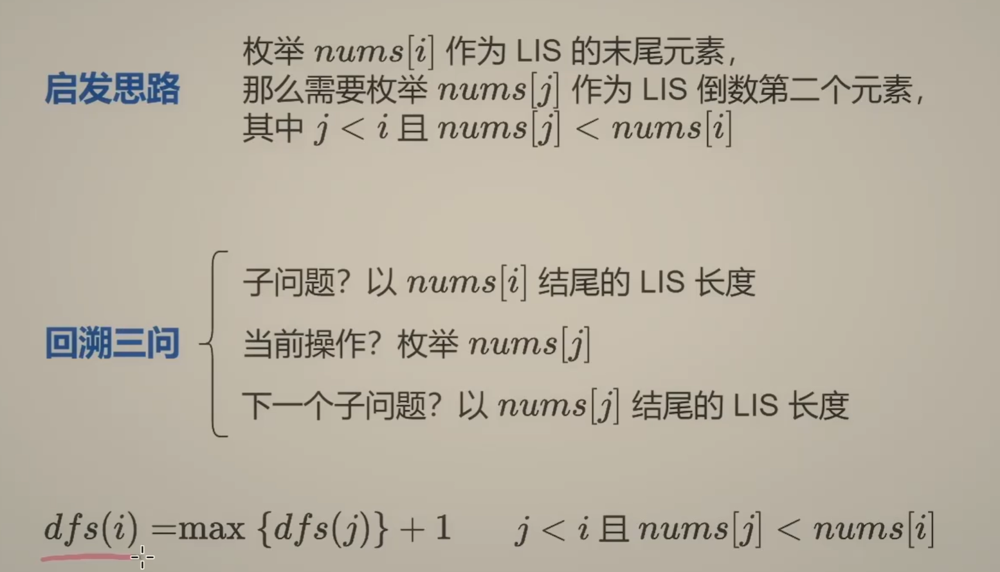


In [ ]:
#枚举选哪个：
#1.记忆化搜索
#时间复杂度：O(n*n) 状态个数*单个状态的计算时间
#空间复杂度：O(n)
class Solution:
    def lengthOfLIS(self, nums) -> int:
        n = len(nums)
        f = [0] * n
        def dfs(i):#dfs函数求解的是以索引i为结尾的数组的最长递增子序列，但是整个数组的LIC不一定是以这个索引作为结尾，因此还要计算以不同索引结尾的最大长度，也就是说不是结尾索引越大LIC就越长
            res = 0
            for j in range(i):
                if nums[j] < nums[i]:
                    if f[j]:
                        res = max(res,f[j])
                    else:
                        res = max(res,dfs(j))#这个计算的结果不包括索引i处的长度，因此最后需要加1
                f[i] = res + 1
            return res + 1#返回的是以nums[i]结尾的子数组的最长递增子序列，但不一定是最长的
        return max(dfs(i) for i in range(n))#

#2.动态规划：
#时间复杂度：O(n*n) 状态个数*单个状态的计算时间
#空间复杂度：O(n)
class Solution:
    def lengthOfLIS(self, nums) -> int:
        n = len(nums)
        f = [0] * n#f数组中存储的是以nums[i]结尾的LIC长度

        for i in range(n):#表示当前数组的结尾索引，这个索引的字符串是要选择的，因此最后加一
            for j in range(i):#
                if nums[j] < nums[i]:
                    f[i] = max(f[i],f[j])
            f[i] += 1
        return max(f)

#3.可以采用求解LCS的思路求解严格递增子序列的问题，将数组去重后排序，那么对于这个新的数组，它的每一个子序列都是严格递增的，再去求这个数组与原数组的最长公共子序列即可，如果没有要求严格递增的话，那么无需去重直接排序即可。
#时间复杂度：O(n*n) 状态个数*单个状态的计算时间
#空间复杂度：O(n)

方法二：

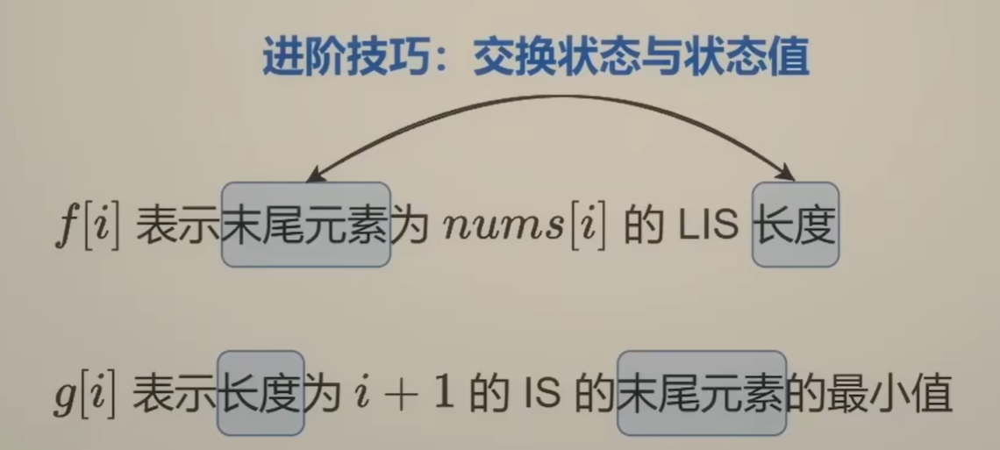

在LS相同的情况下我们只保存末尾元素最小的那个值，因为末尾元素越小，后续LS的长度才有可能越大

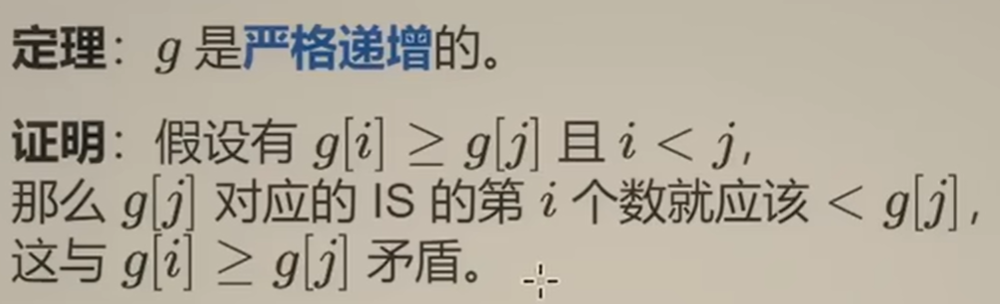
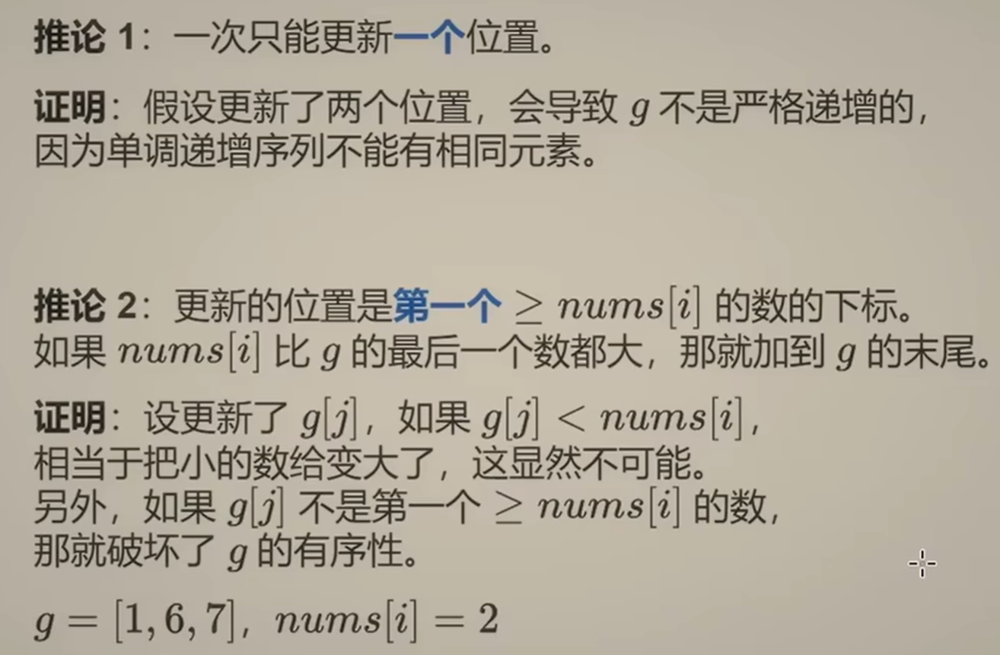

In [ ]:
from bisect import bisect_left
#贪心算法+二分查找
#时间复杂度：n * log(n)
#空间复杂度：0(n)
class Solution:
    def lengthOfLIS(self, nums) -> int:
        g = []
        for x in nums:
            j = bisect_left(g,x)#返回g中第一个>=nums[i]的索引
            if j == len(g):#如果x比g数组中的所有个元素都要大，将其直接添加在数组末尾
                g.append(x)
            else:
                g[j] = x#对于这个x元素而言，以它结尾的严格递增的序列长度为j+1
        return len(g)

#优化
#空间复杂度变为O(1)
class Solution:
    def lengthOfLIS(self, nums) -> int:
        gt = 0
        for x in nums:
            j = bisect_left(nums,x,0,gt)#在nums数组的0与gt的范围内查找>=x的值,搜索范围是一个左闭右开区间
            if j == gt:#当在[0, gt)范围内没有找到符合条件的元素时，bisect_left会返回gt，如果x比g数组中的所有元素都要大，将其直接添加在数组末尾
                nums[gt] = x#因为当前数组的范围为[0,gt)，加入新元素后就变成了[0,gt+1),因此在nums[gt]的位置添加新的值
                gt += 1
            else:
                nums[j] = x
        return gt

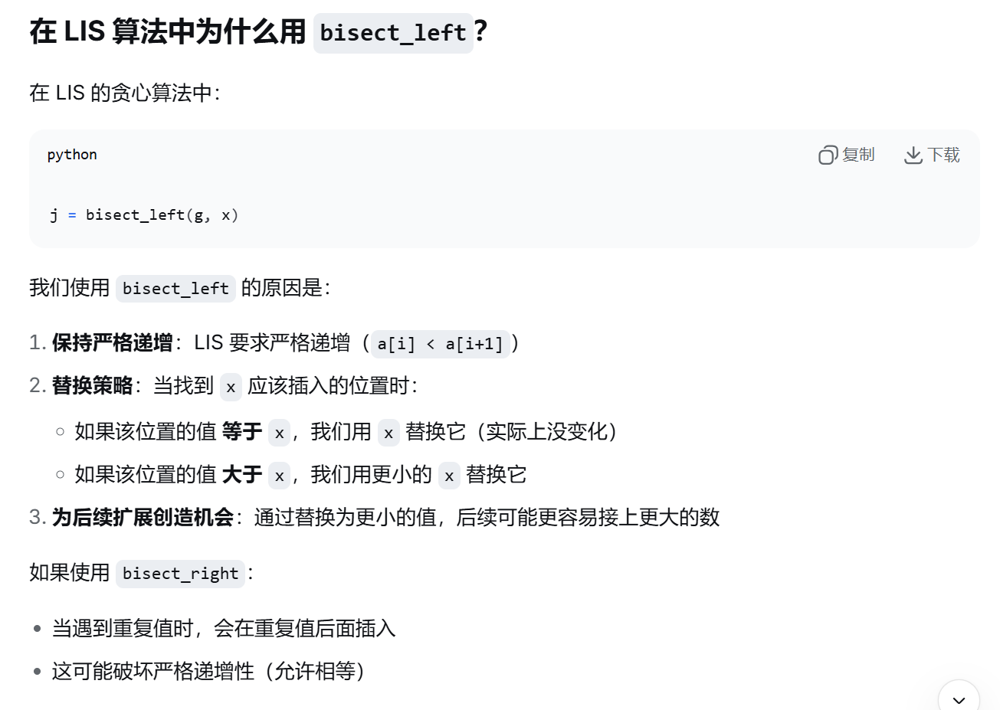
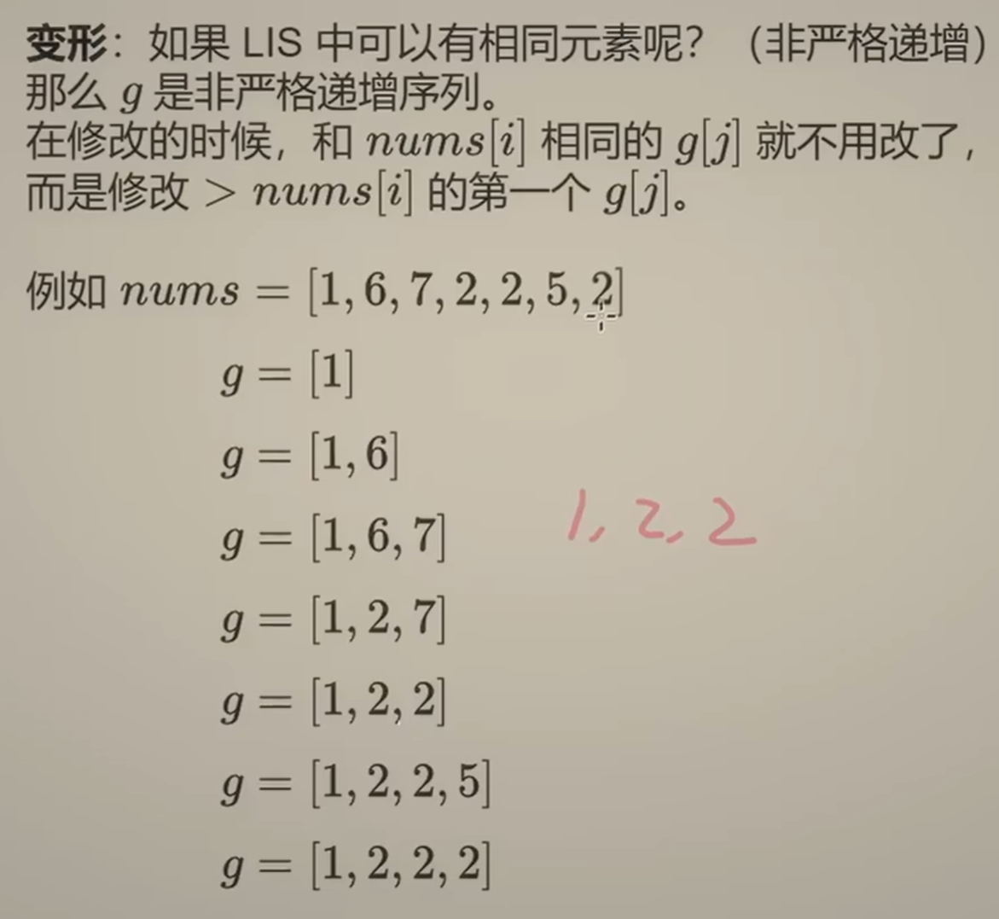

扩展：

**_找出从每个位置为止的最长有效障碍路线_**

此题与LIS问题的不同之处在于求解的是以某个元素为止的非递减序列的长度，而不是整个数组的最长递增子序列的长度



In [ ]:
from bisect import bisect_right

class Solution:
    def longestObstacleCourseAtEachPosition(self, obstacles):
        g = []
        ans = []
        for x in obstacles:#循环保证了障碍物出现的次序
            j = bisect_right(g,x)
            if j == len(g):
                g.append(x)
            else:#找到了第一个大于x的元素，那么将其替换为x后，左边的值都小于x，因此从索引0到j的障碍物都是有效的，而x右边的障碍物高度都要大于x，因此无效
                g[j] = x
            ans.append(j+1)

        return ans

In [ ]:
class Solution:
    def minimumMountainRemovals(self, nums) -> int:
        n = len(nums)
        #这道题与求解最长递增子序列的问题有一些不同，在求解LIC的问题上，我们通过返回g数组的长度知道整个数组的LIC是多少，但是对于每个索引而言，当求解以它结尾的IC或者以它开头的DC的时候，只有g数组的长度是不够的。因此我们可以创建suf与pre数组来存储这些值。
        suf = [0] * n#含义是以nums[i]开头的严格递减子序列的长度
        g1 = []
        for i in range(n-1,-1,-1):#倒序遍历严格递增，那么正序遍历就是严格递减的。
            x = nums[i]
            j = bisect_left(g1,x)
            if j == len(g1):
                g1.append(x)
            else:
                g1[j] = x
            suf[i] = j + 1#当j == len(nums)的时候，说明g1里面的所有值都比x小，这时候以它开头或者结尾的最长IC或者DC就是j + 1,而当是另一种情况的时候，j是第一个大于等于x的数字，将其替换后从0到j的所有数是严格递增且小于等于x,因此长度也是j+1

        max_num = 0
        g2 = []

        for i,x in enumerate(nums):
            pre = 0#含义是以nums[i]为结尾的严格递增子序列的长度
            j = bisect_left(g2,x)
            if j == len(g2):
                g2.append(x)
            else:
                g2[j] = x
            pre = j + 1

            if pre >= 2 and suf[i] >= 2:
                max_num = max(max_num,pre+suf[i]-1)

        return n - max_num

**_#8.买卖股票问题：（状态机DP）_**
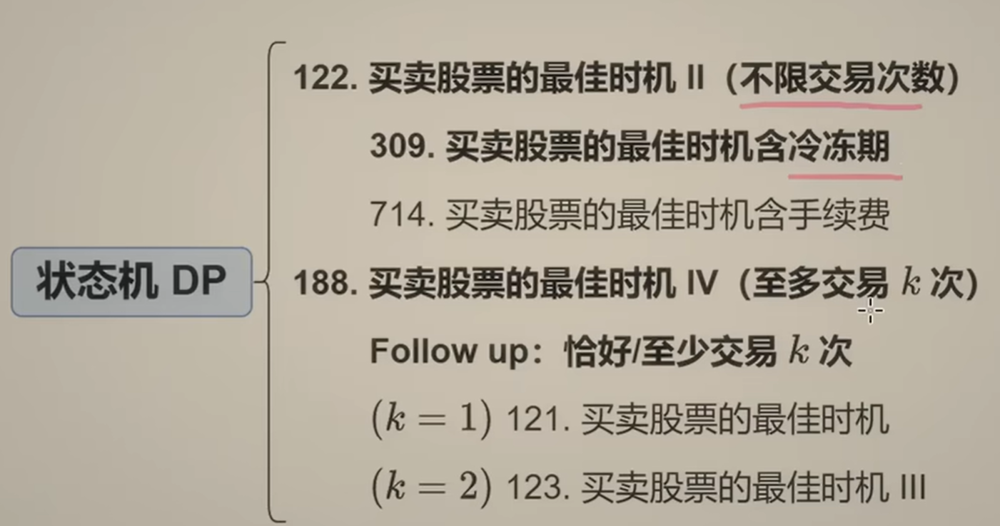
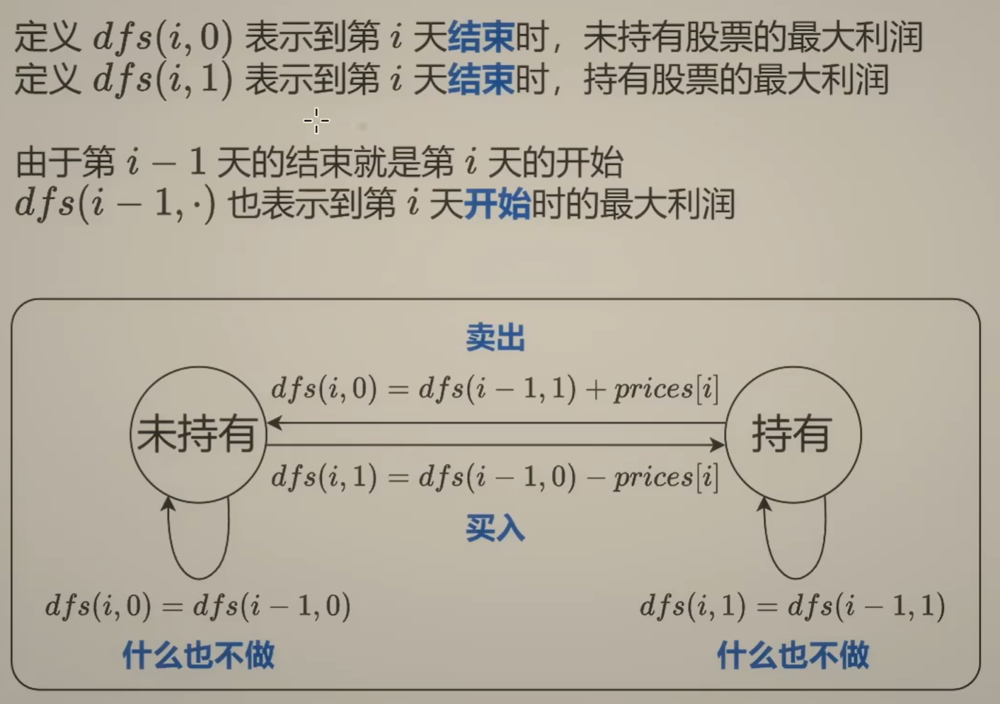

#1.不限制交易次数：

    #没有冷冻期
    #1.递归写法：
    class Solution:
        def maxProfit(self, prices) -> int:
            n = len(prices)
            @cache
            def dfs(i,hold):
                if i < 0:
                    return -inf if hold else 0#当第0天有股票不合法，第0天无股票返回0
                if hold:
                    return max(dfs(i-1,True),dfs(i-1,False)-prices[i])
                else:
                    return max(dfs(i-1,False),dfs(i-1,True)+prices[i])

        # return dfs(n-1,False)

    #2.动态规划写法：
        f0 = 0
        f1 = -inf

        for i,price in enumerate(prices):#天数与价值是一一对应的，因此不能使用两个循环
            new_f0 = max(f0,f1 + price)
            f1 = max(f1,f0 - price)
            f0 = new_f0

        return f0

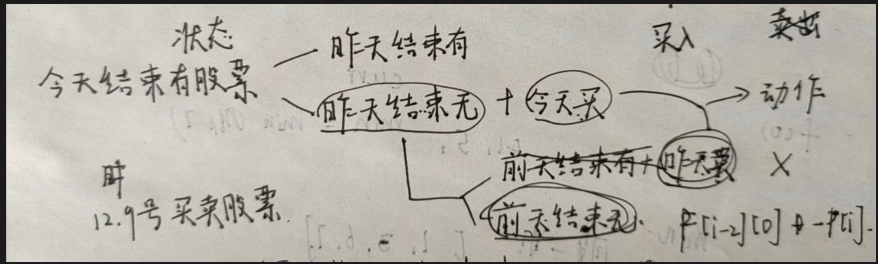

当你在昨天卖出股票后今天就不能买入股票了，因此在今天有股票的情况下，昨天无股票与前天无股票是等价的

    #存在冷冻期：
    #1.递归写法：
    class Solution:
        def maxProfit(self, prices: List[int]) -> int:
            n = len(prices)
            @cache
            def dfs(i,hold):
                if i < 0:
                    return -inf if hold else 0
                if hold:
                    return max(dfs(i-1,True),dfs(i-2,False)-prices[i])
                else:
                    return max(dfs(i-1,False),dfs(i-1,True)+prices[i])

        return dfs(n-1,False)

    #2.动态规划写法
        f0 = 0 #昨天
        f1 = -inf #昨天
        f2 = 0 #前天

        for i,price in enumerate(prices):#天数与价值是一一对应的，因此不能使用两个循环
            new_f0 = max(f0,f1 + price)
            f1 = max(f1,f2 - price)
            f2 = f0
            f0 = new_f0

        return f0


#2.限制交易次数：
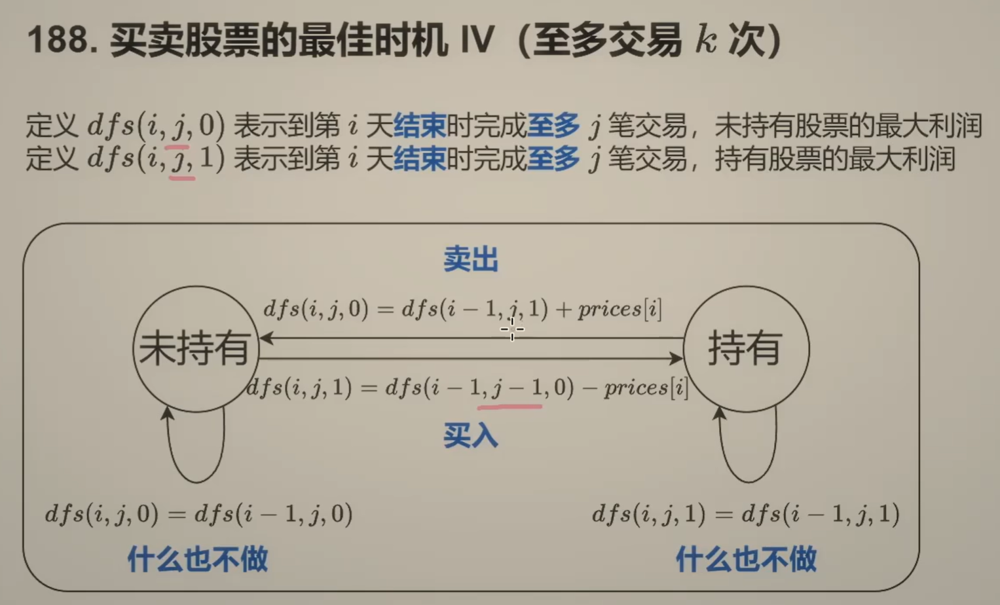
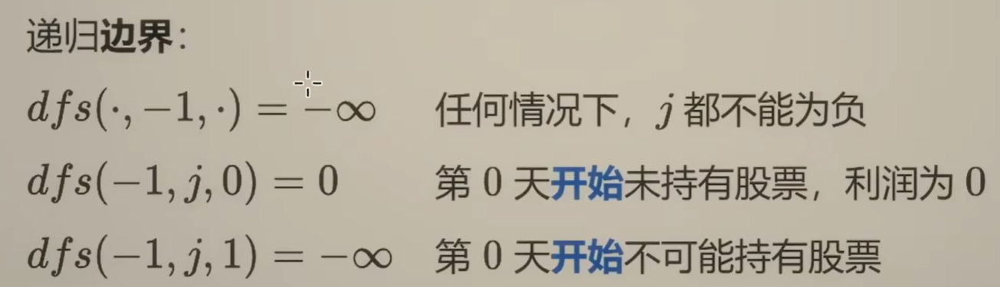

#1.至多交易k次的问题：

![image.png](attachment:968ca632-406b-453e-b49d-7683481af062.png)
对于操作数而言，等于0意味着什么也没做，大于0代表着完成了k笔交易，只有当小于0的时候是不合法的，因此对于一个至多交易k次的问题，应该有k+2个空间来存储不同的情况


    #递归写法
    class Solution:
        def maxProfit(self, k: int, prices: List[int]) -> int:
            n = len(prices)
            @cache
            def dfs(i,hold,j):
                if j < 0:#当操作数为0时意味着什么也不做，仍然是有意义的
                    return -inf
                if i < 0:
                    return -inf if hold else 0
                if hold:
                    return max(dfs(i-1,True,j),dfs(i-1,False,j)-prices[i])
                else:
                    return max(dfs(i-1,False,j),dfs(i-1,True,j-1)+prices[i])

        return dfs(n-1,False,k)

     #动态规划写法
        f = [[-inf]*2 for _ in range(k+2)]#存储的是在操作数为k的情况下昨天持有或未持有股票赚的钱数，更新后
                                          变成今天。
                                          #循环到第i天的时候第i-1天的状态
        for j in range(1,k+2):
            f[j][0] = 0
        for i,p in enumerate(prices):#这里写两重循环的原因在于存在交易数的限制，计算出当前这一天买入或者卖出
                                      股票时不同操作数能获取的最大价值
            for j in range(k+1,0,-1):#倒序更新保证了在计算f[j][0]时，f[j-1][1]是来自前一天的状态，而不是今天刚
            更新过的状态。这是典型的动态规划中避免状态被当前轮次污染的技术，类似于01背包问题中为了避免重复选取物品
            而采用倒序遍历容量。

                f[j][1] = max(f[j][1],f[j][0] - p)#先更新买入在更新卖出
                f[j][0] = max(f[j][0],f[j-1][1] + p)
        return f[k+1][0]

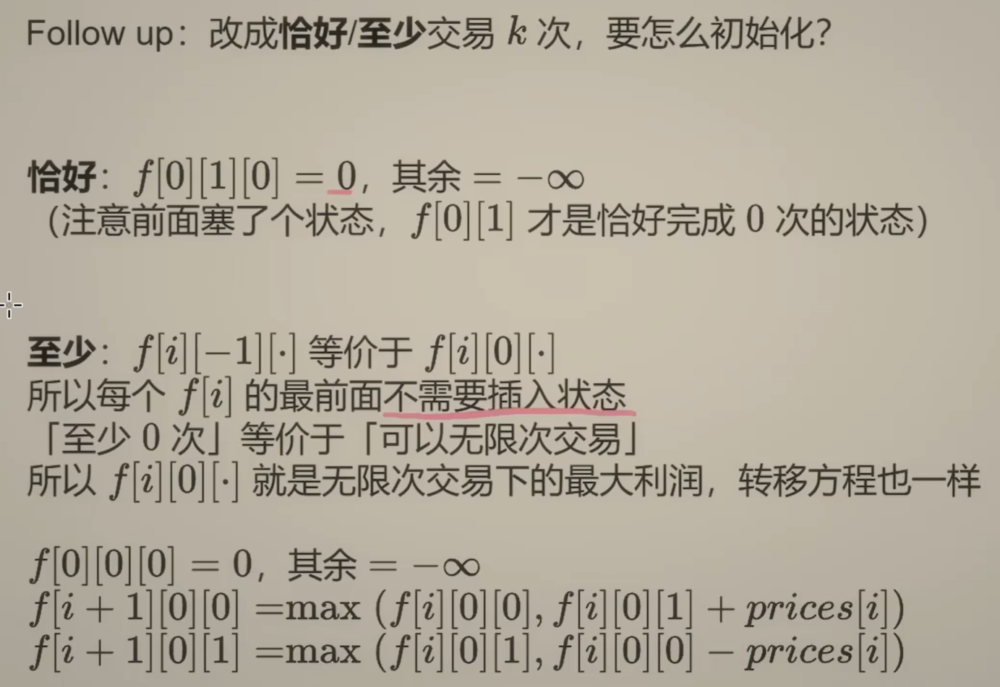

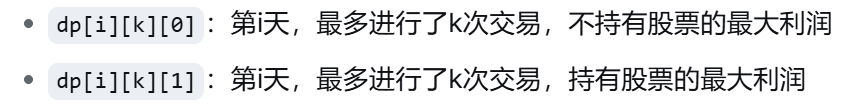

f[i+1][0][.]的含义是在第i+1天交易数至少为0的情况下持有股票与不持有股票所能获得最大利润，就是无限次交易下的最大利润

对于恰好完成k次的问题，若用一个二维数组进行初始化，那么f[1][0]就代表着第-1天操作数为0的情况下不持有股票的利润，此时为0是合理的，持有股票不合理，而对于操作数大于0的情况，因为这时候还没接触到股票，所以不可能有买与卖的操作，因此都是非法的，这一点与至多交易k次不同，对于第-1天没有接触到股票，至多交易k次的话在此时也只能交易0次，0次包含在k次内，有合法的结果，因此初始化为0.

In [ ]:
from cmath import inf

# 恰好
class Solution:
    def maxProfit(self, k: int, prices) -> int:
        # 递推
        n = len(prices)
        f = [[[-inf] * 2 for _ in range(k + 2)] for _ in range(n + 1)]
        f[0][1][0] = 0  # 只需改这里
        for i, p in enumerate(prices):
            for j in range(1, k + 2):
                f[i + 1][j][0] = max(f[i][j][0], f[i][j][1] + p)
                f[i + 1][j][1] = max(f[i][j][1], f[i][j - 1][0] - p)
        return f[-1][-1][0]

        # 记忆化搜索
        # @cache
        # def dfs(i: int, j: int, hold: bool) -> int:
        #     if j < 0:
        #         return -inf
        #     if i < 0:
        #         return -inf if hold or j > 0 else 0
        #     if hold:
        #         return max(dfs(i - 1, j, True), dfs(i - 1, j - 1, False) - prices[i])
        #     return max(dfs(i - 1, j, False), dfs(i - 1, j, True) + prices[i])
        # return dfs(n - 1, k, False)

In [ ]:
# 至少
class Solution:
    def maxProfit(self, k: int, prices) -> int:
        # 递推
        n = len(prices)
        f = [[[-inf] * 2 for _ in range(k + 1)] for _ in range(n + 1)]
        f[0][0][0] = 0#第一天，操作数至少为0，不持有股票的利润为0
        for i, p in enumerate(prices):
            f[i + 1][0][0] = max(f[i][0][0], f[i][0][1] + p)
            f[i + 1][0][1] = max(f[i][0][1], f[i][0][0] - p)  # 无限次
            for j in range(1, k + 1):
                f[i + 1][j][0] = max(f[i][j][0], f[i][j][1] + p)
                f[i + 1][j][1] = max(f[i][j][1], f[i][j - 1][0] - p)
        return f[-1][-1][0]

        # 记忆化搜索
        # @cache
        # def dfs(i: int, j: int, hold: bool) -> int:
        #     if i < 0:
        #         return -inf if hold or j > 0 else 0
        #     if hold:
        #         return max(dfs(i - 1, j, True), dfs(i - 1, j - 1, False) - prices[i])
        #     return max(dfs(i - 1, j, False), dfs(i - 1, j, True) + prices[i])
        # return dfs(n - 1, k, False)

**_#9.最长回文子序列（区间dp问题）_**

对于区间dp问题而言，空间上一般不能简化，二维是必须的
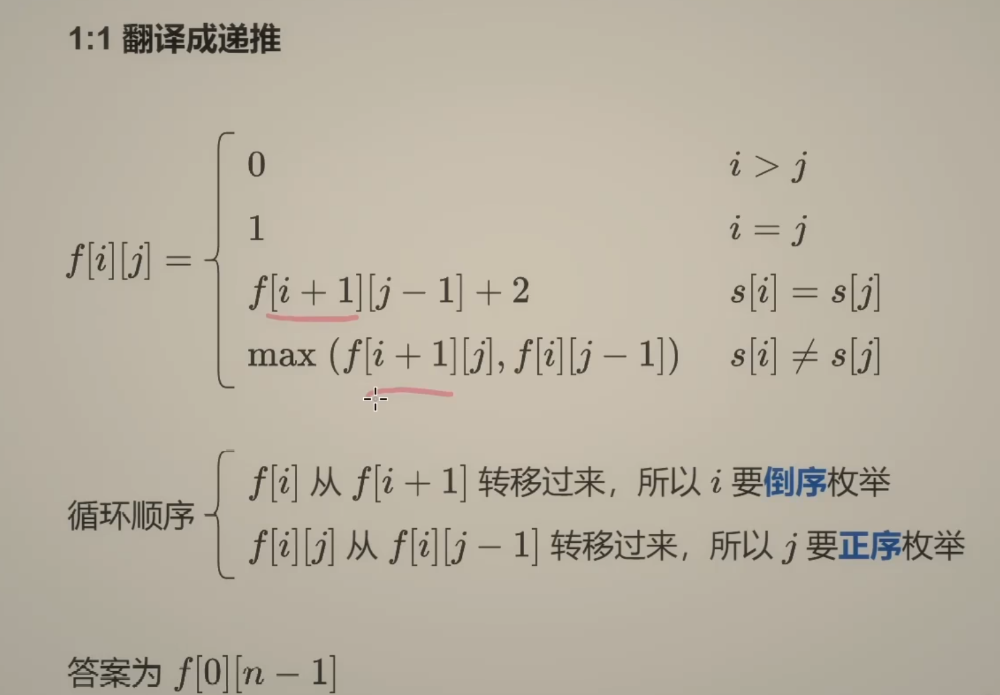

In [ ]:
#1，递归写法
#时间复杂度为0(n*2)：因为left与right都有n个取值，所以有n*2个状态，每个状态只需计算一次。
# @cache
        # def dfs(left,right):
        #     if left == right:
        #         return 1
        #     elif left > right:
        #         return 0
        #     elif s[left] == s[right]:
        #         return dfs(left+1,right-1) + 2
        #     else:
        #         return max(dfs(left,right-1),dfs(left+1,right))# 不匹配时如果舍弃left，就取left+1，如果舍弃right，就取right-1.

        # left,right = 0,len(s)-1
        # return dfs(left,right)

#2.动态规划写法：
#时间复杂度：0(n*2)
#空间复杂度：0(n*2)

        n = len(s)
        f = [[0] * n for _ in range(n)]

        num = 0
        for left in range(n-1,-1,-1):
            f[left][left] = 1
            for right in range(left+1,n):
                if s[left] == s[right]:
                    f[left][right] = f[left+1][right-1] + 2
                else:
                    f[left][right] = max(f[left+1][right],f[left][right-1])
        return f[0][n-1]

**_#10.多边形三角剖分的最低得分(区间dp问题)_**

    回溯三问：
    1.当前操作：在(i，j)的范围内枚举一个数k
    2.子问题：求解(i,j)的最低得分
    3.下一个子问题：求解(i,k)与(k,j)的最低得分

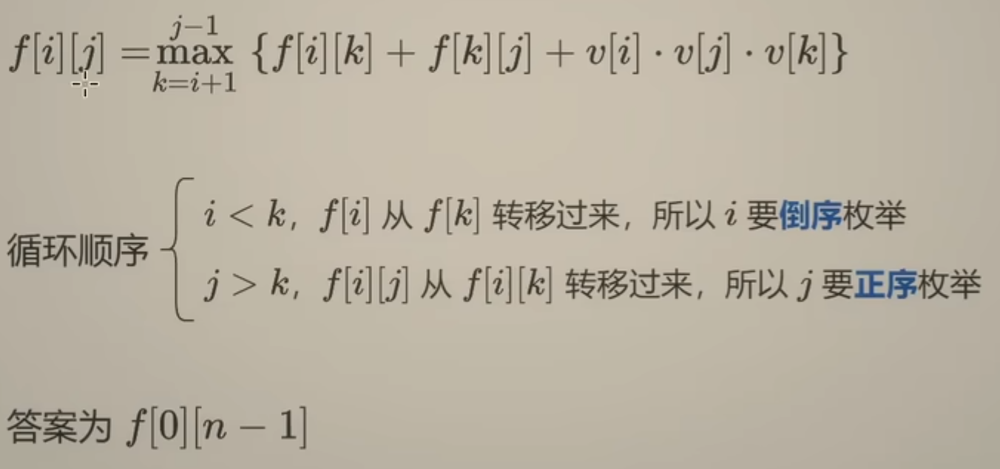

In [ ]:
class Solution:
    def minScoreTriangulation(self, values) -> int:
        n = len(values)
        # @cache
        # def dfs(i,j):
        #     if i + 1 == j :#因为我们枚举是在（i,j）的开区间上进行的，当满足这个条件的时候意味着区间内没有值了，结束递归。
        #         return 0
        #     min_num = inf
        #     for x in range(i+1,j):#i与j不要选，枚举x
        #         curr_num = values[i] * values[j] * values[x]
        #         min_num = min(curr_num+dfs(i,x)+dfs(x,j),min_num)
        #     return min_num
        # return dfs(0,n-1)

        f = [[0] * n for _ in range(n)]
        for i in range(n-3,-1,-1):#从n-3开始时才能保证j有意义
            for j in range(i+2,n):#当j=i+1时，开区间内没有值，所以从i+2开始
                res = inf#这句话要放在下面的循环外面，这样才是枚举k时的最小值，否则的话只是将当前的k值与inf进行比较
                for k in range(i+1,j):
                    curr_num = values[i] * values[j] * values[k]
                    res = min(curr_num+f[i][k]+f[k][j],res)
                f[i][j] = res
        return f[0][n-1]

**_#11.回文子串：_**

是用动态规划思路解答这个问题的关键在于想清楚dp数组的含义，[i,j]的含义不是从i到j的字符字串中含有多少回文子串，而是判断这个子串是不是一个回文串，因此dp数组有True与False构成，通过统计True的数量来判断整个字符串中回文串的数量。

In [ ]:
#时间复杂度：0(n*2)
#空间复杂度：O(n*2)
class Solution:
    def countSubstrings(self, s: str) -> int:
        n = len(s)
        f = [[False] * n for _ in range(n)]
        res = 0
        for i in range(n-1,-1,-1):
            for j in range(i,n):
                if s[i] == s[j]:
                    if j - i <= 1:
                        f[i][j] = True
                        res += 1
                    else:
                        if f[i + 1][j - 1]:
                            f[i][j] = True
                            res += 1
        return res

**_#12.最长回文子串_**
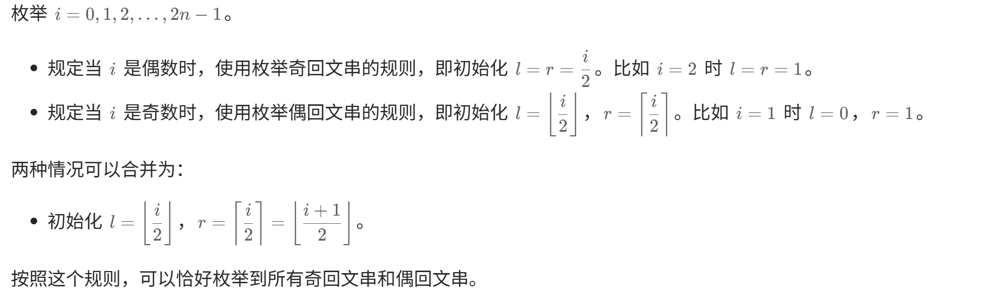
使用这种方法通过一次循环就实现了对每个位置的奇回文串与偶回文串的检查

In [ ]:
class Solution:
    def longestPalindrome(self, s: str) -> str:
        n = len(s)
        ans_left = ans_right = 0
        for i in range(2 * n - 1):#这里为2*n-1是因为首先l与r都经过了除2的操作，为了使所有的字符都能够作为回文串的中心，因此要乘2，同时，如果是2*n的话存在r越界的风险。
            l = i // 2
            r = (i + 1) // 2
            while l >= 0 and r < len(s) and s[l] == s[r]:
                l -= 1
                r += 1
            if r - l - 1 >= ans_right - ans_left:#因为左闭右开，所以字符长度right - left即可
                ans_left,ans_right = l+1,r#左闭右开区间，为了匹配后续字符的输出

        return s[ans_left:ans_right]

**_#13.最长有效括号：_**
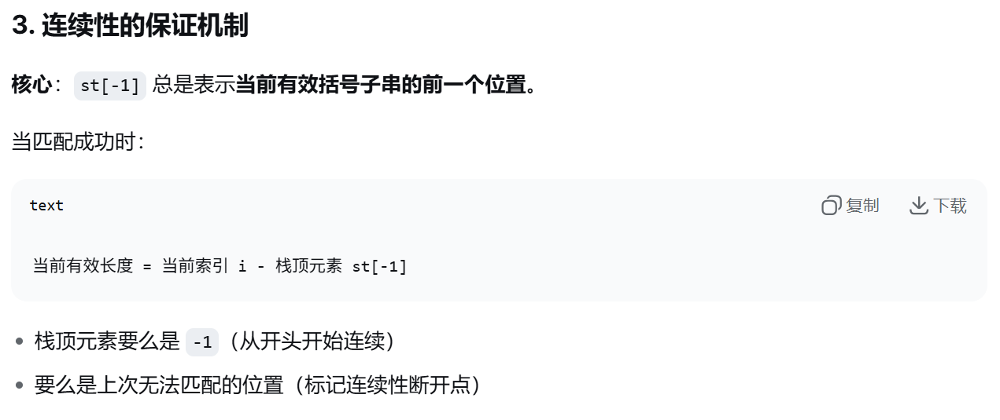
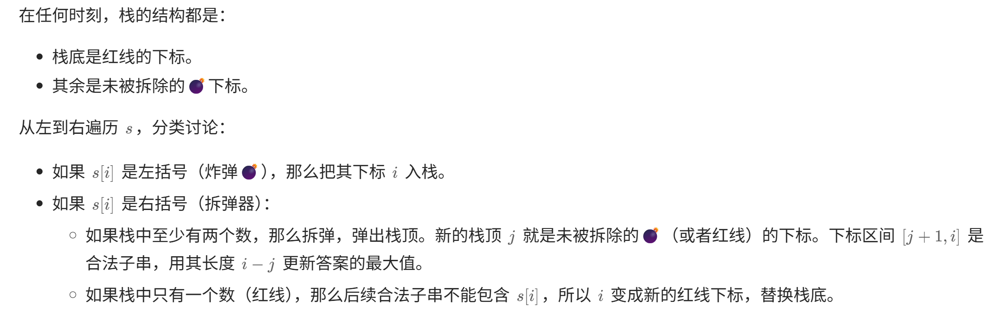

In [ ]:
class Solution:
    def longestValidParentheses(self, s: str) -> int:
        st = [-1]
        max_num = 0
        for i,char in enumerate(s):
            if char == '(':
                st.append(i)
            elif len(st) > 1:
                st.pop()
                max_num = max(max_num,i - st[-1])
            else:
                st[-1] = i
        return max_num

**_#14.单词拆分问题_**
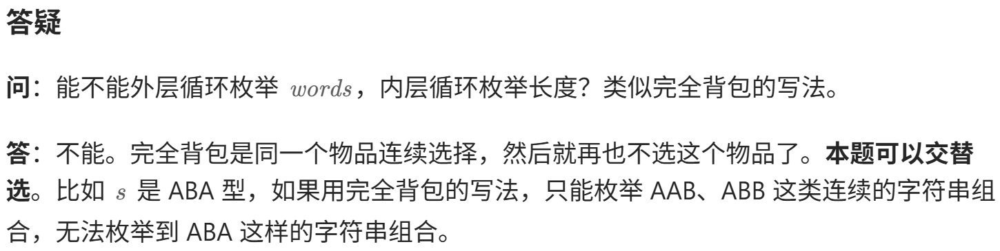

f数组代表着索引i之前的字符串能否被拆分，因此只需考虑f[n]是否为True即可。

In [ ]:
class Solution:
    def wordBreak(self, s: str, wordDict) -> bool:
        max_len = max(map(len,wordDict))#map() 函数：将指定的函数应用到可迭代对象的每个元素上
        wordDict = set(wordDict)
        n = len(s)
        f = [False] * (n + 1)
        f[0] = True
        for i in range(1,n+1):
            for j in range(i-1,max(i - max_len-1,-1),-1):#max(i - max_len-1,-1)如果i - max_len大于0的话，那么倒序便遍历的时候不用遍历到-1，因为当遍历到i-max_len的时候，在长度方面就只有字典中最长的单词满足要求了，再往后肯定找不到单词
                if f[j] and s[j:i] in wordDict:
                    f[i] = True
                    break
        return f[n]

**_#15.使数组严格递增_**

f[i] 表示：以 a[i] 结尾（且 a[i] 不被替换）时，前 i+1 个元素中最多能保留多少个不替换的元素

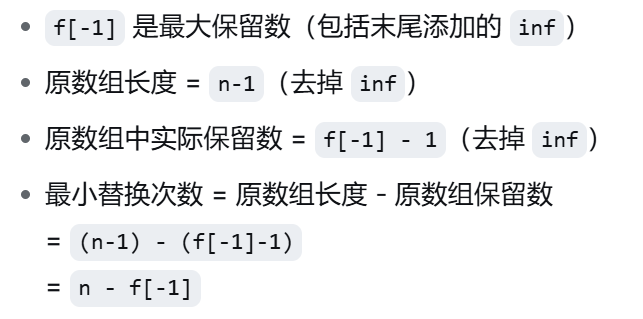
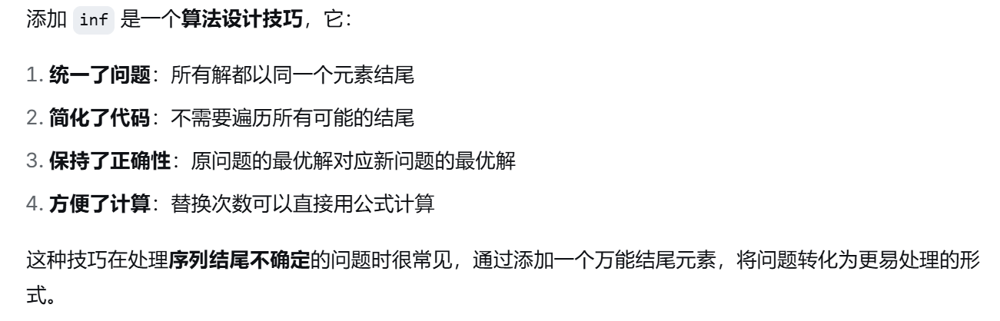

In [ ]:
from functools import cache
#选与不选思路
#dfs(i,pre)的含义是构建[0,i]的严格递增数组，并且数组的最后一个值小于pre
class Solution:
    def makeArrayIncreasing(self, a, b) -> int:
        b.sort()  # 为能二分查找，对 b 排序

        @cache  # 缓存装饰器，避免重复计算 dfs 的结果
        def dfs(i: int, pre: int) -> int:
            if i < 0:
                return 0
            res = dfs(i - 1, a[i]) if a[i] < pre else inf  # 不替换 a[i]
            k = bisect_left(b, pre) - 1  # 二分查找 b 中小于 pre 的最大数的下标，不管这个值能不能被替换，都要考虑被替换也就是不选的情况
            if k >= 0:  # a[i] 替换成小于 pre 的最大数
                res = min(res, dfs(i - 1, b[k]) + 1)
            return res

        ans = dfs(len(a) - 1, inf)  # 假设 a[n-1] 右侧有个无穷大的数
        return ans if ans < inf else -1

In [ ]:
#枚举选哪个思路
class Solution:
    def makeArrayIncreasing(self, arr1, b) -> int:
        a = arr1 + [inf]  # 简化代码逻辑，如果没有inf的话，最大保留数应该是max(f),跟LIS问题一样，最大保留数不一定是以最后一个元素结尾的，这个元素有可能被替代了
        b = sorted(set(b))  # 去重+排序
        n = len(a)  # 注意 a 已经添加了一个元素
        f = [0] * n  # 这里初始化成任何值都行
        for i, x in enumerate(a):
            k = bisect_left(b, x)
            res = 0 if k >= i else -inf  # 当小于x的数目大于i的时候，意味着从0到i-1的所有元素都可以被替换，因此初始化保留元素为0，否则的话初始化为-inf，因为我们现在求的是能保留的不被替换元素的最大值。
            if i and a[i - 1] < x:  # 无替换
                res = max(res, f[i - 1])
            for j in range(i - 2, max(i - k - 2, -1), -1):#这一步操作替换的是从a[j+1]到a[i-1]的i-j-1个元素，所以在进行替换时，首先要保证小于x的元素数目k>=i-j-1,如果不成立的话意味着想换i-j-1个数，但是只有k个数，换不了，因此j>=i-k-1,又因为range是左闭右开。又因为索引为0的值一定是没有被替换的，因此从[0,i-1]最多有i-1个被替换的值，当i-1的数量小于k的时候，j到0就结束了，否则的话j<0没有意义，j代表着数组a中上一个被保留的值的索引，这个值最小只能为0，因此当i-k-1小于0的时候，j最小只能取0
                if b[k - (i - j - 1)] > a[j]:
                    # a[j+1] 到 a[i-1] 替换成 b[k-(i-j-1)] 到 b[k-1]，只需要检查第一个替换元素是否大于 a[j]，因为 b 已经排序，后面的元素自然会递增。
                    res = max(res, f[j])
            f[i] = res + 1  # 把 +1 移到这里，表示 a[i] 不替换
        return -1 if f[-1] < 0 else n - f[-1]  # 注意 a 已经添加了一个元素

**_#16.统计打字方案数：_**

模运算公式

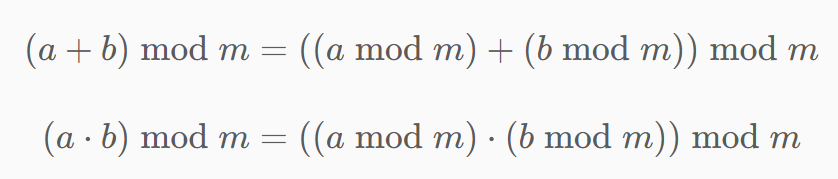
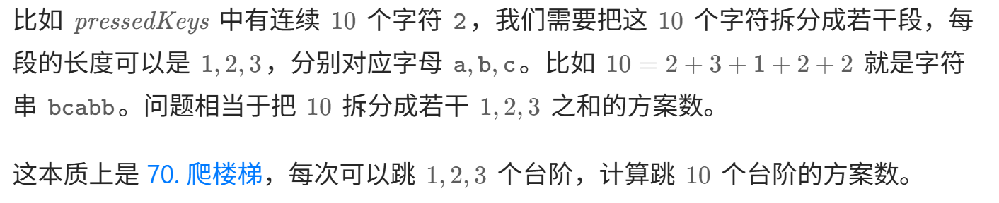

In [ ]:
from itertools import groupby

Mod = 1_000_000_007
f = [1,1,2,4]
g = [1,1,2,4]
for _ in range(10**5 - 3):#提前记录当有n个相同的元素的时候一共有多少种组合
    f.append((f[-1]+f[-2]+f[-3])%Mod)#代表着按一个键不同次数代表的字母
    g.append((g[-1]+g[-2]+g[-3]+g[-4])%Mod)

class Solution:
    def countTexts(self, pressedKeys: str) -> int:
        ans = 1
        for x,s in groupby(pressedKeys):#用于将连续相同的元素分组，其中x代表键，s代表当前连续相同的字符
            m = len(list(s))
            ans *= g[m]  if x in "79" else f[m]
        return ans%Mod

**_#17.乘法运算的最大分数_**

这个题最难的点在于f数组的理解，f[i][j]计算的是剩余操作的最大分数，也就是从第i+1步操作到第m步的最大分数，而j代表着已经选取了j个左侧的值，同时也指明了当前左指针正指向j这个元素，选取的值不论左右，是不会计入到分数计算里去的，而从f[i+1]到f[i]，剩余的操作数增加，因此对于这一步操作而言，有两种可能，一是将当前左边的值加入到分数计算中，因此选取的左边的元素值-1，反之选取的右边元素的值减去1.

In [ ]:
class Solution:
    def maximumScore(self, nums, multipliers) -> int:
        m = len(multipliers)
        # @cache
        # def dfs(i,j,x):
        #     if x == m:
        #         return 0
        #     y = multipliers[x]
        #     return max(dfs(i,j-1,x+1) + nums[j] * y,dfs(i+1,j,x+1) + nums[i] * y)

        m, n = len(multipliers), len(nums)
        f = [[0] * (m+1) for _ in range(m+1)]#f[m][]代表的是初始状态，此时操作数为m+1,不合法，因此最大分数都为0.
        for i in range(m-1, -1, -1):
            for left in range(i+1):
                f[i][left] = max(multipliers[i] * nums[left] + f[i+1][left+1], multipliers[i] * nums[n-1-i+left] + f[i+1][left])
        return f[0][0]
#反向DP:f[i][j]的含义是从第i次操作开始，左边已经取了left个，能获得的最大分数
#正向DP:f[i][j]的含义是前i次操作，左边取了left个，获得的最大分数
#这个题中，f[i][j]表示：当我们正要执行第 i+1 次操作（对应使用乘数 multipliers[i]）时，且在执行这次操作前，已经从 nums 的左端一共取了 j 个元素（右端则取了 i - j 个元素）；在这个状态下，从「第 i 次操作」到「最后一次操作（第 m-1 次）」的所有剩余操作中，能获得的最大分数，计算的是排除这部分取得元素后能获取的最大分数

**_树形dp：_**

_**树形dp的方法保证了在无向图中，无论从哪个节点开始递归，都能返回最长直径**_

**_#18.相邻字符不同的最长路径_**
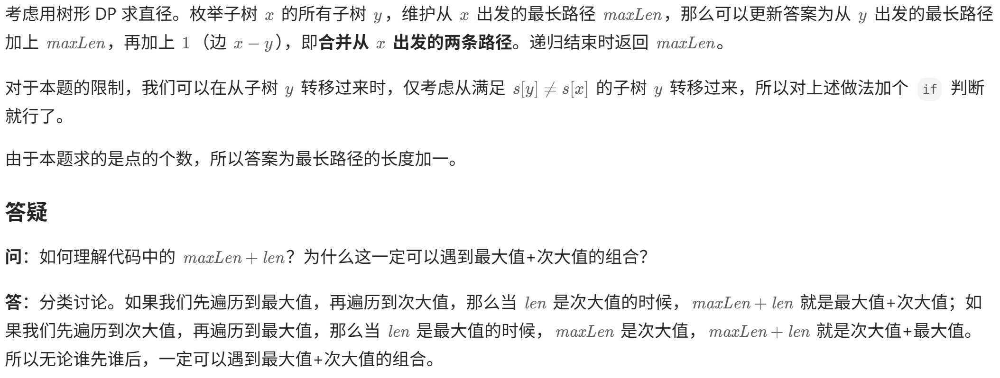

In [ ]:
class Solution:
    def longestPath(self, parent, s: str) -> int:
        n = len(parent)
        f = [[] for _ in range(n)]
        for i in range(1,n):
            f[parent[i]].append(i)
        res = 0
        def dfs(i):#当处理的是无向图的问题时，在dfs中加入fa表示父节点，并在遍历子节点的时候加入y!=fa的判断即可
            nonlocal res
            x_len = 0#以i这个节点为根节点某一条分支的边的数目
            for y in f[i]:
                y_len = dfs(y) + 1#dfs要在判断外面，因为如果在里面的话当条件不成立的时候res不能进行更新
                if s[y] != s[i]:
                    res = max(res,x_len + y_len)
                    x_len = max(x_len,y_len)
            return x_len#返回的是当这个节点作为叶子结点时的最大路径

        dfs(0)
        return res + 1#最后加1来表示求解的是边数

**_#19.最大价值和与最小价值和的差值：_**

In [ ]:
class Solution:
    def maxOutput(self, n: int, edges, price) -> int:
        g = [[] for _ in range(n)]
        for x, y in edges:
            g[x].append(y)
            g[y].append(x)  # 建树

        ans = 0
        def dfs(x: int, fa: int):#计算的是以x节点为拐点的路径的最大价值，这条路径需要减去其中一个叶子节点
            nonlocal ans
            max_s1 = p = price[x]
            max_s2 = 0#max_s1,max_s2的作用与max_len一致，用于记录遍历到的以当前节点x为根节点的包含叶子节点与不包含的当前最大值，当根节点不是叶子结点的时候，二者都包含price[x]的值。
            for y in g[x]:
                if y == fa: continue#对于没有环的无向图而言，如果y!= fa那么这个节点就没有被遍历过
                s1, s2 = dfs(y, x)#s1,s2中不包含节点x的值，但包含y的值(在y不是叶子节点的情况下)
                # 前面最大带叶子的路径和(包含根节点)+ 当前不带叶子的路径和(不包含根节点)
                # 前面最大不带叶子的路径和 + 当前带叶子的路径和
                ans = max(ans, max_s1 + s2, max_s2 + s1)
                max_s1 = max(max_s1, s1 + p)
                max_s2 = max(max_s2, s2 + p)  # 这里加上 p 是因为 x 必然不是叶子
            return max_s1, max_s2
        dfs(0, -1)
        return ans

**_#20.统计子树中城市之间的最大距离_**

思想：利用枚举子集的思想以及求树的直径的思路，首先创建一个in_set数组来对每个节点进行选与不选的操作，当i==n的时候，对前n个节点我们都已经做出了选择，接下来就是判断由这些节点构成的in_set是否是一个子集，以及是子集的话直径是多少，构建vis数组来记录遍历过的节点，对于此题而言，无向且联通，因此对于in_set数组中任意一个为True的节点而言，以这个节点开始遍历的话能遍历到所有与它相连接的节点并得到该子树的直径，而当vis！= in_set的时候，证明当前是一片森林而非子树，不连通，因此它的值是不会被记录的。因此需要使用break语句来提前结束for循环。

In [ ]:
class Solution:
    def countSubgraphsForEachDiameter(self, n: int, edges):
        g = [[] for _ in range(n)]
        for x,y in edges:
            g[x-1].append(y-1)
            g[y-1].append(x-1)
        in_set = [False] * n
        res = [0] * (n-1)
        def f(i):
            if i == n:
                diameter = 0
                vis = [False] * n
                for i,y in enumerate(in_set):
                    if not y:continue

                    def dfs(x):
                        nonlocal diameter
                        max_len = 0
                        vis[x] = True
                        for y in g[x]:
                            if not vis[y] and in_set[y]:#对于已经遍历过的节点y而言，在计算以它为根节点的直径的时候肯定已经考虑了包含以x为根节点的最长路径的情况，因此不需要在遍历已经遍历过的节点？
                                curr_len = dfs(y) + 1
                                diameter = max(diameter,curr_len + max_len)
                                max_len = max(max_len,curr_len)
                        return max_len

                    dfs(i)
                    break

                if diameter and vis == in_set:
                    res[diameter-1] += 1
                return

            f(i+1)
            in_set[i] = True
            f(i+1)
            in_set[i] = False
        f(0)
        return res

做法二：利用位运算

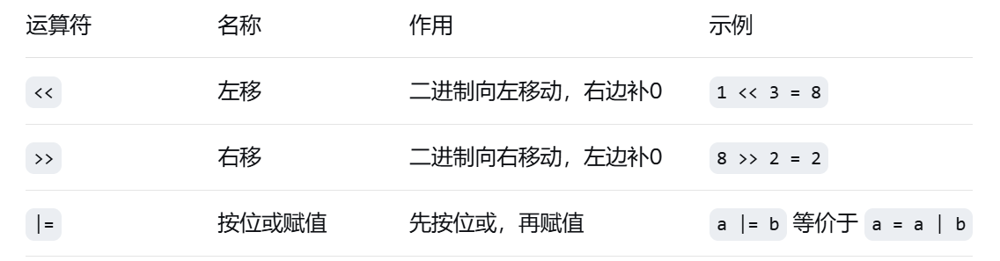

In [ ]:
class Solution:
    def countSubgraphsForEachDiameter(self, n: int, edges):
        # 建树
        g = [[] for _ in range(n)]
        for x, y in edges:
            g[x - 1].append(y - 1)
            g[y - 1].append(x - 1)  # 编号改为从 0 开始

        ans = [0] * (n - 1)
        #  二进制枚举，用二进制数来表示节点的选与不选，二进制从低到高第 i 位为 1 表示 i 在集合中，为 0 表示 i 不在集合中，例如集合 {0,2,3} 对应的二进制数为 1101
        for mask in range(3, 1 << n):# 需要至少两个点，所以从011（3）开始
            if (mask & (mask - 1)) == 0:  #用于判断mask中是否只有一位为1，==的优先级比&高，因此要有括号。
                continue
            # 求树的直径
            vis = diameter = 0
            def dfs(x: int) -> int:#传入的是城市在g数组中的序号，因此对于第i个城市而言，它的序号是i-1,对应的位置是i。
                nonlocal vis, diameter
                vis |= 1 << x  #将第x位标记为1，也就是记录遍历到的第x+1个节点
                max_len = 0
                for y in g[x]:
                    if (vis >> y & 1) == 0 and mask >> y & 1:  # y 没有访问过且在 mask 中，(x >> n) & 1 得到的是原始数字的第n位。
                        ml = dfs(y) + 1
                        diameter = max(diameter, max_len + ml)
                        max_len = max(max_len, ml)
                return max_len
            dfs(mask.bit_length() - 1)  # 从一个在 mask 中的点开始递归，返回最高位1的位置，这个点肯定被选中了。
            #bit_length()返回一个二进制数至少需要几位来表示，返回的值可以理解为最高位上1的位置，在减去1就代表着被选中的节点
            if vis == mask:
                ans[diameter - 1] += 1
        return ans

做法三：枚举直径端点+乘法原理
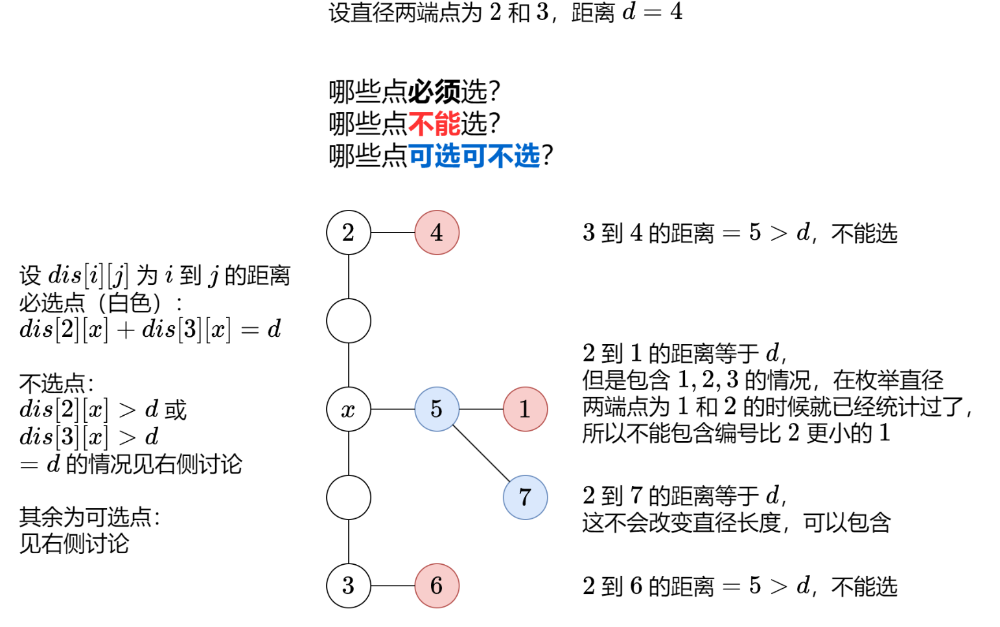

In [ ]:
class Solution:
    def countSubgraphsForEachDiameter(self, n: int, edges):
        # 建树
        g = [[] for _ in range(n)]
        for x, y in edges:
            g[x - 1].append(y - 1)
            g[y - 1].append(x - 1)  # 编号改为从 0 开始

        # 计算树上任意两点的距离
        dis = [[0] * n for _ in range(n)]
        def dfs(x: int, fa: int) -> None:
            for y in g[x]:
                if y != fa:
                    dis[i][y] = dis[i][x] + 1  # 自顶向下
                    dfs(y, x)
        for i in range(n):
            dfs(i, -1)  # 计算 i 到其余点的距离，最开始的时候计算的是i到它的子节点的距离，进一步递归计算的就是i到子节点的子节点的距离，以此类推求出从i出发到达某个点的距离。

        def dfs2(x: int, fa: int) -> int:
            # 能递归到这，说明 x 可以选
            cnt = 1  # 选 x
            for y in g[x]:#判断x的子节点构成的子树的选择问题，因为这些子树的选与不选是互相独立的，所以利用乘法原理
                if y != fa and \
                   (di[y] < d or di[y] == d and y > j) and \
                   (dj[y] < d or dj[y] == d and y > i):  # 满足这些条件就可以选
                    cnt *= dfs2(y, x)  # 每棵子树互相独立，采用乘法原理
            if di[x] + dj[x] > d:  # x 是可选点而非必选点，也就是说点没有在直径的路径上
                cnt += 1  # 不选 x
            return cnt
        ans = [0] * (n - 1)
        for i, di in enumerate(dis):
            for j in range(i + 1, n):
                dj = dis[j]
                d = di[j]
                ans[d - 1] += dfs2(i, -1)
        return ans

**_树上最大独立集_**

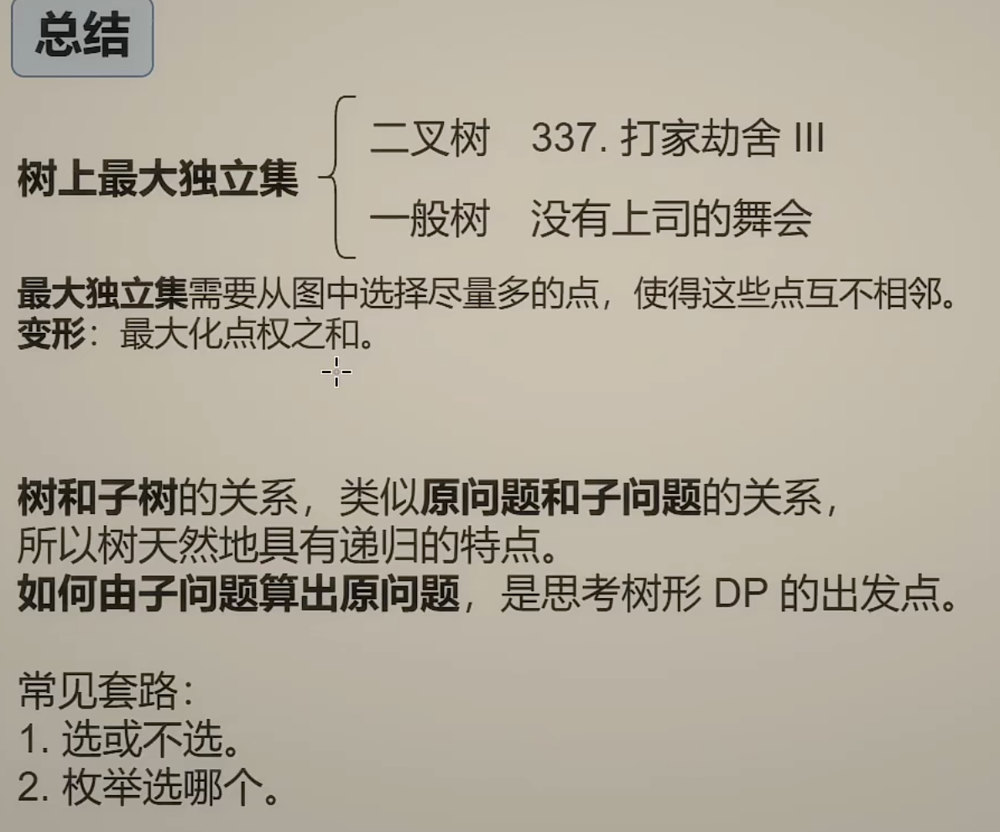

**_#21.打家劫舍III_**
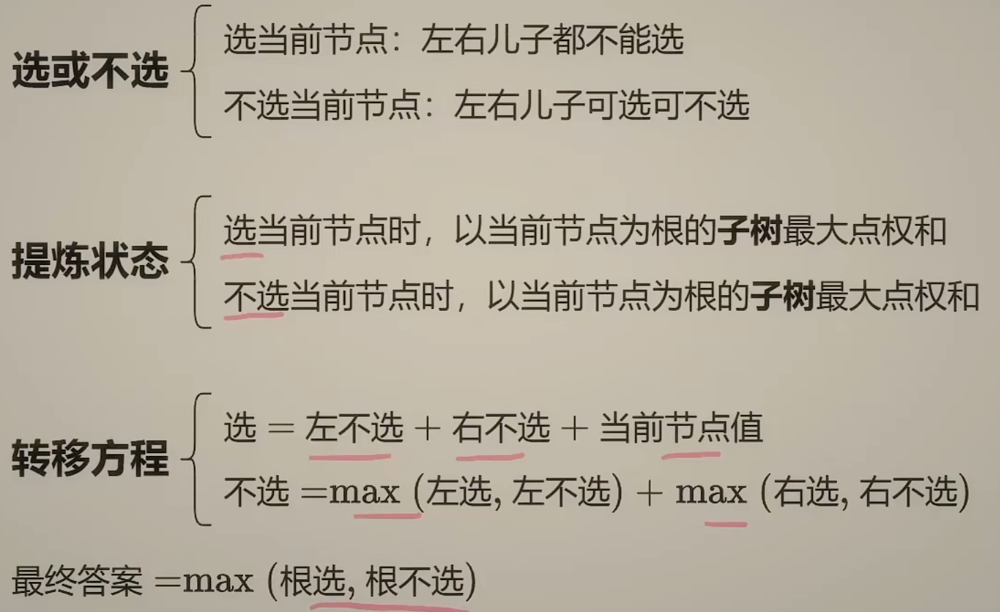

In [ ]:
#采用类似状态机的思路：对于每个节点而言，返回选这个节点的值与不选这个节点的值来表示两种状态。
class Solution:
    def rob(self, root) -> int:
        def dfs(node):
            if not node:
                return 0,0
            l_rob,l_not_rob = dfs(node.left)
            r_rob,r_not_rob = dfs(node.right)
            rob,not_rob = node.val + l_not_rob + r_not_rob,max(l_rob,l_not_rob) + max(r_rob,r_not_rob)
            return rob,not_rob
        return max(dfs(root))

In [ ]:
#一般树版本
class Solution:
    def rob(self, happy,relation,n) -> int:
        f = [[] for _ in range(n)]
        indegree = [0] * n
        for chi,par in relation:
            f[par-1].append(chi-1)
            indegree[chi-1] += 1#名为chi的节点存储在chi-1的索引下
        root = next(i for i in range(n) if indegree[i] == 0)#找到第一个入读为0的节点，也就是根节点。

        def dfs(i):
            if not f[i]:
                return 0,0
            sel,not_sel = 0,0
            for y in f[i]:#通过循环的方式遍历当前节点的子节点，并将子节点选与不选时的点权和进行累加
                y_sel,y_not_sel = dfs(y)
                sel += y_not_sel#当前这个节点要选，那么将这个节点的子节点不选情况下的点权和进行累加
                not_sel += max(y_sel,y_not_sel)#当前这个节点不选的时候，它的子节点可选可不选，记录这两种情况的最大值
            return sel+happy[i],not_sel
        return max(dfs(root))

**_#22.监控二叉树_**

此题的核心是针对每个节点，从节点的不同状态入手，分析节点在不同状态下的最小数目或者最小点权和。
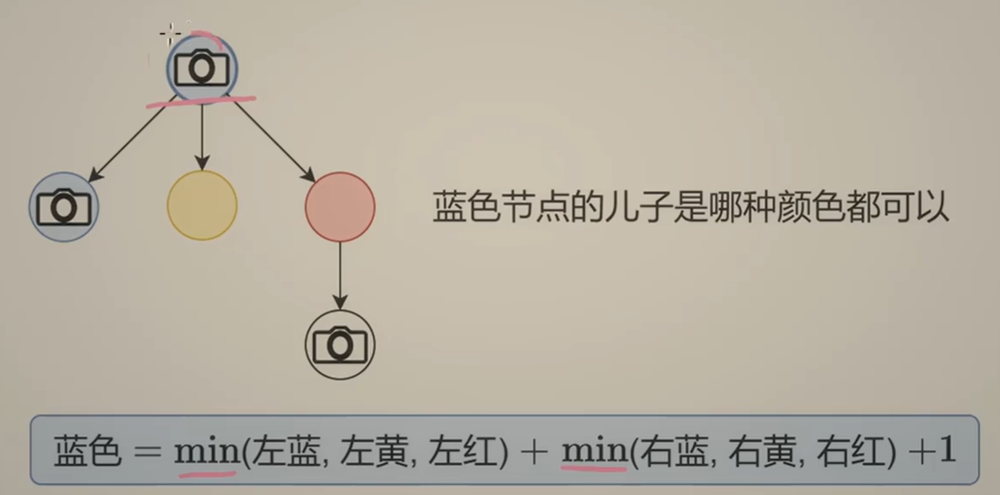
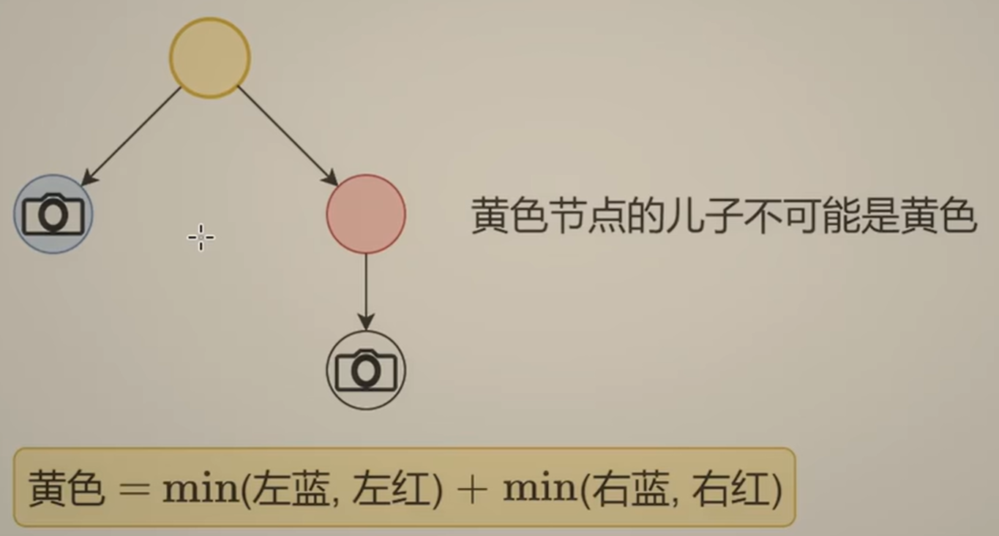
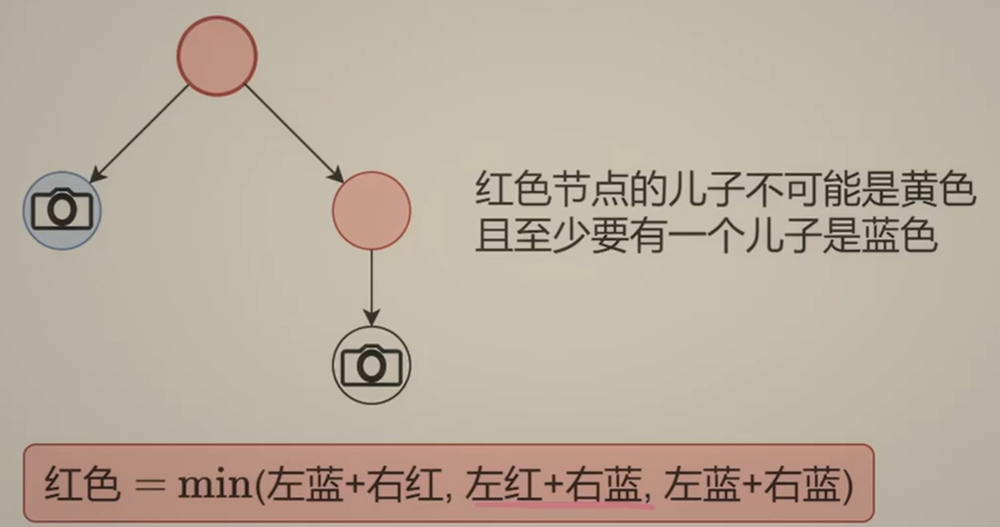
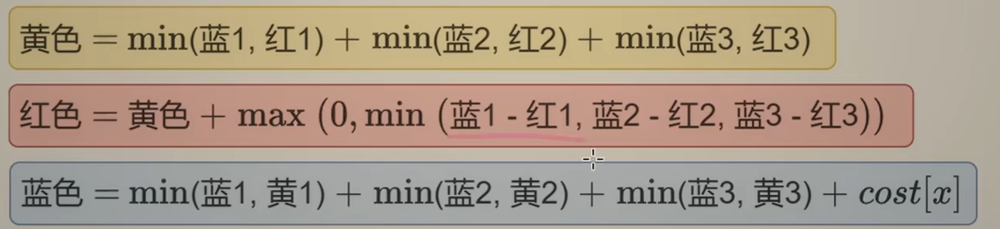

分析一下红色节点的处理逻辑，对于红色节点而言，它必须有一个子节点是蓝色节点，而对于黄色节点而言，它的子节点是由红色与蓝色构成的，因此可以在黄色的基础上构建答案，当黄色的结果中包含至少一个蓝色节点的时候，那么此时红色与黄色的值相同，而当黄色的子节点都是红色的时候，意味着对于任意一个子节点而言，蓝色的值比红色要大，因此我们可以选择将其中的一个红色节点进行替换，选择的依据是找到choose - by_fa最小的节点（但要大于0，否则黄色的结果中已经包含蓝色节点）进行变色，从而保证红色的结果在满足要求的情况下最小。同时从图中也可看出红色的代价值一定大于等于黄色，因此在节点为蓝色的时候不用去判断子节点为红色的情况。

**_二叉树版本的代码会处理到空节点，而一般树版本的代码只会处理到叶子节点。_**
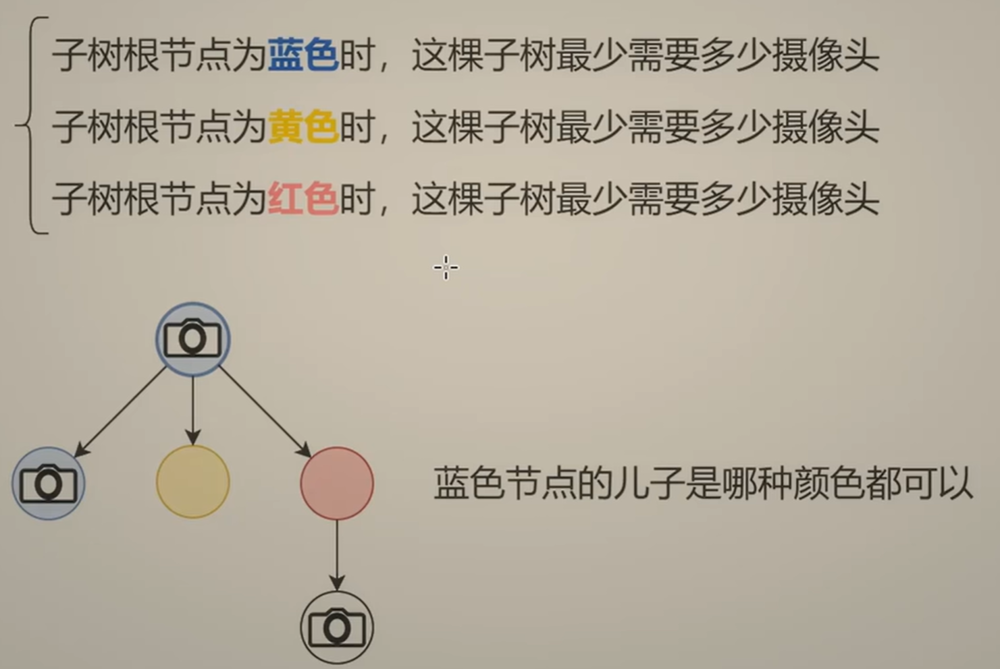

In [ ]:
#二叉树版本代码：
class Solution:
    def minCameraCover(self, root) -> int:
        def dfs(node):#dfs可以理解为当node节点作为根节点是覆盖所由节点的最小数目
            if not node:
                return inf,0,0#对于一个空节点而言，是不可能安装监控的，因此choose的情况下返回inf，虽然对于一个空节点而言，不可能有子节点，因此by_children的结果也不存在，但我们返回的值更注重对当前节点的处理，也就是说当前节点安不安装更加重要，因此被孩子监控的情况下，当前节点不安监控，返回0即可。
            l_choose,l_by_fa,l_by_children = dfs(node.left)
            r_choose,r_by_fa,r_by_children = dfs(node.right)
            choose = min(l_choose,l_by_fa) + min(r_choose,r_by_fa) + 1#把1改成cost[x]，变成监控所有节点的最小花费。
            by_fa = min(l_choose,l_by_children) + min(r_choose,r_by_children)#对于一个叶子节点而言，当被它的父亲监控的时候，by_fa = 0,但如果空节点的by_children设置为inf，那么by_fa的值为inf，显然是不对的，因此设置为0.
            by_children = by_fa + max(0,min(l_choose-l_by_children,r_choose-r_by_children))
            return choose,by_fa,by_children
        choose,_,by_children = dfs(root)
        return min(choose,by_children)

In [ ]:
#一般树版本代码：
class Solution:
    def minCameraCover(self,n,edges,cost) -> int:
        f = [[] for _ in range(n)]
        indegree = [0] * n
        for chi,par in edges:
            f[par].append(chi)
            indegree[chi] += 1

        def dfs(x):
            choose = cost[x]
            by_fa = 0
            min_num = inf
            for y in f[x]:
                y_choose,y_by_fa,y_by_children = dfs(y)
                choose += min(y_choose,y_by_fa)
                by_fa += min(y_choose,y_by_children)
                min_num = min(y_choose - y_by_children,min_num)
            by_children = by_fa + max(0,min_num)
            return choose,by_fa,by_children
        root = next(i for i in range(n) if indegree[i] == 0)
        choose,_,by_children = dfs(root)
        return max(choose,by_children)